In [1]:
import os, copy
import glob
import logging

import numpy as np
import scipy.optimize as so
import pandas as pd
import xarray as xr
import rioxarray as rxr
import datetime as dt
import cartopy.crs as ccrs

import netCDF4
import h5py
from osgeo import gdal

#%matplotlib widget
import matplotlib as mpl
import matplotlib.pyplot as plt
import colorcet as cc


import hgrs
import hgrs.driverEnMAP as driverEnMAP

opj = os.path.join
hgrs.__version__

'1.0.7'

### Set PRISMA file paths
Give path for L1C (L2C is normally in the same directory). The L2C is needed to get the viewing geometry parameters (viewing zenith angle, sun zenith angle and relative azimuth)


In [2]:

cams_dir = '/data/cams/world/'
odir = '/data/satellite/enmap/l2a'
l1c_dir= '/data/satellite/enmap/EnMAP_L1C/AAOT'
l1c_paths =glob.glob(opj(l1c_dir,'ENMAP*Z'))
l1c_paths

['/data/satellite/enmap/EnMAP_L1C/AAOT/ENMAP01-____L1C-DT0000141797_20250704T104344Z_003_V010502_20250715T181045Z',
 '/data/satellite/enmap/EnMAP_L1C/AAOT/ENMAP01-____L1C-DT0000001199_20220623T104348Z_016_V010502_20250308T051722Z',
 '/data/satellite/enmap/EnMAP_L1C/AAOT/ENMAP01-____L1C-DT0000049235_20231107T105849Z_003_V010502_20250130T134329Z',
 '/data/satellite/enmap/EnMAP_L1C/AAOT/ENMAP01-____L1C-DT0000029821_20230729T104016Z_002_V010502_20250130T132154Z',
 '/data/satellite/enmap/EnMAP_L1C/AAOT/ENMAP01-____L1C-DT0000068034_20240408T102534Z_002_V010502_20250121T114551Z',
 '/data/satellite/enmap/EnMAP_L1C/AAOT/ENMAP01-____L1C-DT0000001704_20220716T104012Z_015_V010502_20250130T025935Z',
 '/data/satellite/enmap/EnMAP_L1C/AAOT/ENMAP01-____L1C-DT0000021765_20230609T104401Z_002_V010502_20250130T132154Z',
 '/data/satellite/enmap/EnMAP_L1C/AAOT/ENMAP01-____L1C-DT0000012881_20230408T103718Z_002_V010502_20250130T135837Z',
 '/data/satellite/enmap/EnMAP_L1C/AAOT/ENMAP01-____L1C-DT0000068707_2024

In [ ]:
for l1c_path in l1c_paths:
    basename = os.path.basename(l1c_path)
    l2a_path = opj(odir,basename.replace('L1C','L2A')+'.nc')
    if os.path.exists(l2a_path):
        continue
    driver = hgrs.Driver('enmap')
    
    l1c_prod = driver.driver(l1c_path,reflectance_unit=True)
    l1c_prod.Rtoa.load()
    date_str = str(l1c_prod.time.dt.strftime('%Y-%m').values)
    cams_path = opj(cams_dir,f'cams_forecast_{date_str}.nc')
    
    raster = l1c_prod.sza.rio.reproject(4326)
    clon, clat = float(raster.x.mean()),float(raster.y.mean())
    
    lut_file='/DATA/git/satellite_app/hgrs/data/lut/opac_osoaa_lut_v3_light.nc'
    lut_file='/data/vrtc/xlut/toa_lut_opac_wind_up_v3.nc'
    
    aero_lut = xr.open_dataset(lut_file).isel(wind=1).drop_sel(model='URBA_rh70').squeeze()
    aero_lut['wl'] = aero_lut['wl'] * 1000
    
    date = l1c_prod.time
    
    # -----------------------------------------
    # Create hGRS object
    # -----------------------------------------
    logging.info('Create hGRS object')
    prod = hgrs.Algo(l1c_prod, expon=1.5, xcoarsen=20, ycoarsen=20)
    prod.round_angles()
    prod.wl_atmo = slice(950, 2300)
    prod.aero_lut = aero_lut
    
    # -----------------------------------------
    # get CAMS and set atmospheric parameters
    # -----------------------------------------
    logging.info('get CAMS and set atmospheric parameters')
    # lazy loading
    cams = xr.open_dataset(cams_path, decode_cf=True,
                           chunks={'time': 1, 'x': 500, 'y': 500})
    # slicing
    #
    cams = cams.sel(latitude=clat, longitude=clon, method='nearest')
    # fix for new ADS format (sept 2024)
    if ('forecast_period' in cams.dims) & ('forecast_reference_time' in cams.dims):
        cams = cams.stack(time_buffer=['forecast_period', 'forecast_reference_time']).swap_dims(
            {'time_buffer': 'valid_time'}).sortby('valid_time').rename(
            {'valid_time': 'time'}).drop_vars(['time_buffer'])
    
    cams = cams.sel(time=date, method='nearest')
    
    # select OPAC aerosol model
    # aod = cams[['aod355', 'aod380', 'aod400', 'aod440', 'aod469', 'aod500', 'aod550', 'aod645', 'aod670',
    #            'aod800', 'aod865', 'aod1020', 'aod1064', 'aod1240', 'aod1640', 'aod2130']].to_pandas()
    # aod.index = aod.index.str.replace('aod', '').astype(int)
    # cams_aod = aod.to_xarray().rename({'index': 'wl'})
    cams_wls = [469, 550, 670, 865, 1240]
    param_aod = []
    for wl in cams_wls:
        wl_ = str(wl)
        param_aod.append('aod' + wl_)
    
    cams_aod = cams[param_aod].to_array(dim='wl')
    
    wl_cams = cams_aod.wl.str.replace('aod', '').astype(float)
    cams_aod = cams_aod.assign_coords(wl=wl_cams)
    
    # new LUT:
    
    lut_aod = aero_lut.aot.sel(aot_ref=1).interp(wl=cams_aod.wl)
    idx = np.abs((cams_aod / cams.aod550) - lut_aod).sum('wl').argmin()
    opac_model = aero_lut.model.values[idx]
    print(opac_model)
    
    # set gases and pressure
    prod.pressure = float(cams.sp) * 1e-2
    prod.to3c = float(cams.gtco3)
    prod.tno2c = float(cams.tcno2)
    prod.tch4c = float(cams.tc_ch4)
    
    # -----------------------------------------
    # Apply water masking
    # -----------------------------------------
    logging.info('Apply water masking')
    prod.apply_water_masks()
    
    # -----------------------------------------
    # Construct coarse resolution raster
    # -----------------------------------------
    logging.info('Construct coarse resolution raster')
    prod.get_coarse_masked_raster()
    # prod.plot_water_pix_number()
    
    # -----------------------------------------
    # Correct for gaseous absorption
    # -----------------------------------------
    logging.info('Correct for gaseous absorption')
    prod.get_gaseous_transmittance()
    prod.other_gas_correction()
    
    logging.info('water vapor retrieval and correction')
    wv_retrieval = hgrs.WaterVapor(prod)
    wv_retrieval.solve()
    
    prod.get_wv_transmittance_raster(wv_retrieval.water_vapor)
    prod.water_vapor_correction()
    
    # ------------------------------------------
    # aerosol retrieval
    # ------------------------------------------
    logging.info('aerosol retrieval')
    
    variable = 'Rtoa'
    prod.coarse_masked_raster = prod.remove_wl_dataset(
        prod.coarse_masked_raster, prod.wl_to_remove, variable=variable)
    
    # TODO double check regularization from CAMS AOT values
    aod550_mean = cams.aod550.mean().values
    
    aod550_std = cams.aod550.std().values
    aod550_std = np.max([aod550_std, 0.2 * aod550_mean+0.05])
    aot550_min = 0.002# np.max([aod550_mean - 2*aod550_std,0.001])
    aero_retrieval = hgrs.Aerosol(prod,
                                  aerosol_model=opac_model,
                                  first_guess=[aod550_mean, 0.],
                                  aot550_limits=[aot550_min,
                                                 aod550_mean + aod550_std])
    aero_retrieval.solve()
    self = aero_retrieval
    self.prepare_lut(prod.coarse_masked_raster.wl)
    self.smoothing()
    
    #self.aero_img['aot_ref_smoothed']=self.aero_img['aot_ref_smoothed']*0.5
    # construct aot raster
    # with full res
    #aot_ref_vals = self.aot_ref_full.round(3)
    # with coarse res
    aot_ref_vals = self.aero_img['aot_ref_smoothed'].round(3)
    aot_refs = np.unique(aot_ref_vals)
    aot_refs = aot_refs[~np.isnan(aot_refs)]
    # TODO update LUT for aot< 0.001
    aot_refs[aot_refs<0.002]=0.002
    # if rounded aot_ref has unique value
    if len(aot_refs) == 1:
        aot_refs = np.concatenate([ aot_refs, 1.2 * aot_refs])
    aots = self.aot_lut.interp(aot_ref=aot_refs, method='linear')
    aots = aots.interp(aot_ref=aot_ref_vals, method='nearest')
    
    aots.name = 'aot'
    aots.attrs['description'] = 'spectral aerosol optical thickness'
    
    # construct raster for diffuse atmospheric reflectance
    Rdiffs = self.Rtoa_lut.interp(aot_ref=aot_refs, method='linear')
    Rdiffs = Rdiffs.interp(aot_ref=aot_ref_vals, method='nearest')
    Rdiffs.name = 'Rtoa_diff'
    Rdiffs.attrs['description'] = 'top-of-atmosphere atmosphere reflectance'
    
    
    
    # construct raster for direct transmittance due to rayleigh and aerosol
    Tdirs = self.transmittance_dir(aots, self.air_mass, rot=self.rot)
    Tdirs.name = 'Tdir'
    Tdirs.attrs['description'] = 'direct transmittance due to rayleigh and aerosol for total air mass'
    
    
    aero_retrieval.get_atmo_parameters(prod.coarse_masked_raster.wl)
    
    # ------------------------------------------
    # full resolution processing
    # ------------------------------------------
    logging.info('process full resolution')
    
    prod.raster = prod.remove_wl_dataset(prod.raster, prod.wl_to_remove)
    prod.other_gas_correction(raster_name='raster', variable='Rtoa')
    
    # ------------------------------------------
    # water vapor
    # ------------------------------------------
    chunk = 256
    height, width, Nwl = len(prod.raster.y), len(prod.raster.x), len(prod.raster.wl)
    results = np.full((height, width), 0, dtype=np.float32)
    variable = 'Rtoa'
    for iy in range(0, height, chunk):
        yc = min(height, iy + chunk)
        if yc == height:
            continue
        for ix in range(0, width, chunk):
            xc = min(width, ix + chunk)
            if xc == width:
                continue
            raster = prod.raster[variable][:, iy:yc, ix:xc]
            Twv_raster = prod.Twv_raster.interp(x=raster.x,y=raster.y)
            prod.raster[variable].data[:, iy:yc, ix:xc] = raster /  Twv_raster
           
    
    Rdiff_full = aero_retrieval.atmo_img.Rtoa_diff  # .interp(x=prod.raster.x, y=prod.raster.y)
    Tdir_full = aero_retrieval.atmo_img.Tdir  # .interp(x=prod.raster.x, y=prod.raster.y)
    wl_sunglint = prod.wl_sunglint
        
    Rrs = np.full((Nwl,height, width), np.nan, dtype=np.float32)
    BRDF_sunglint = np.full((height, width), np.nan, dtype=np.float32)
    
    for iy in range(0, height, chunk):
        yc = min(height, iy + chunk)
        if yc == height:
            continue
        for ix in range(0, width, chunk):
            xc = min(width, ix + chunk)
            if xc == width:
                continue
                
            Rcorr = prod.raster.Rtoa[:, iy:yc, ix:xc] 
            Rdiff_full_=Rdiff_full.interp(x=Rcorr.x, y=Rcorr.y)
            Rcorr = Rcorr - Rdiff_full_
            
            Tdir_full_=Tdir_full.interp(x=Rcorr.x, y=Rcorr.y)        
    
            sunglint_eps = aero_retrieval.sunglint_eps
            BRDF_sunglint[iy:yc, ix:xc]  = (Rcorr.sel(wl=wl_sunglint) / (Tdir_full_.sel(wl=wl_sunglint)
                                                          * sunglint_eps.sel(wl=wl_sunglint))).mean(dim='wl')
            
            # TODO clean up xarray inheritance of some extra coordinates...
            # BRDF_sunglint = BRDF_sunglint.drop_vars('aot_ref', errors=False).squeeze()
            Rdir = Tdir_full_ * sunglint_eps * BRDF_sunglint[iy:yc, ix:xc] 
            
            Rrs[:,iy:yc, ix:xc]  = (Rcorr - Rdir) / np.pi
    
    l2_prod = xr.Dataset(dict(Rrs=(["wl", "y", "x"], Rrs),
                              brdfg_full=(["y", "x"], BRDF_sunglint), ),
                                   coords=dict(x=prod.raster.x,
                                               y=prod.raster.y,
                                               wl=prod.raster.wl),
                                   )
    
    # finally correct for down and upward transmittances
    # TODO compute pixel wise
    Ttot_Ed = xr.open_dataset('/data/vrtc/xlut/transmittance_lut_opac_wind_v3.nc').isel(wind=1)
    aot_ref = float(aero_retrieval.aero_img.aot_ref.mean())
    wl = l2_prod.Rrs.wl.values
    sza = float(aero_retrieval.sza)
    vza = float(aero_retrieval.vza)
    Ttot_Ed_ = Ttot_Ed.Ttot_Ed.sel(model=opac_model).interp(sza=sza, method='cubic'
                                                            ).interp(aot_ref=aot_ref, method='quadratic').interp(
        wl=wl, method='cubic')
    Ttot_Lu_ = Ttot_Ed.Ttot_Ed.sel(model=opac_model).interp(sza=vza, method='cubic'
                                                            ).interp(aot_ref=aot_ref, method='quadratic').interp(
        wl=wl, method='cubic') ** 1.05
    Ttot = (Ttot_Ed_ * Ttot_Lu_).reset_coords(drop=True)
    l2_prod['Rrs'] = l2_prod.Rrs / Ttot
    
    
    # -----------------------------
    # construct output image
    # -----------------------------
    logging.info('construct final product')
    
    # -----------------------------
    # data
    wv = wv_retrieval.water_vapor.rename({"x": "xc", "y": "yc"})
    aero = aero_retrieval.aero_img.rename({"x": "xc", "y": "yc"})
    water_pixel_prop = (prod.coarse_masked_raster.water_pixel_number / prod.Npix_per_megapix).drop_vars(
        'tcwv').rename({"x": "xc", "y": "yc"})
    water_pixel_prop.name = 'water_pix_prop'
    #geom = prod.raster[['lon', 'lat']].drop_vars('tcwv')
    #Rrs_ = Rrs_l2.reset_coords().drop_vars(['model', 'z']).rename({'tcwv': 'tcwv_full', 'aot_ref': 'aot_ref_full'}).set_coords(['time','spatial_ref'])
    l2_prod = xr.merge([l2_prod, wv, aero,water_pixel_prop])
    #l2_prod['brdfg_full'] = BRDF_sunglint
    
    
    
    param = 'Rrs'
    l2_prod[param].attrs['unit'] = 'per steradian'
    l2_prod[param].attrs['long_name'] = 'Remote sensing reflectance'
    l2_prod[param].attrs['description'] = 'Directional water-leaving radiance normalized ' + \
                                          'by downwelling irradiance in the observation geometry'
    
    param = 'water_pix_prop'
    l2_prod[param].attrs['unit'] = '-'
    l2_prod[param].attrs['description'] = 'Relative number of water pixel within mega-pixel used for inversion'
    
    param = 'brdfg'
    l2_prod[param].attrs['unit'] = '-'
    l2_prod[param].attrs['long_name'] = 'BRDF_sunglint'
    l2_prod[param].attrs['description'] = 'Bidirectional reflectance distribution function ' + \
                                          'estimated from the sunglint in the SWIR for the observation geometry'
    param = 'brdfg_std'
    l2_prod[param].attrs['unit'] = '-'
    l2_prod[param].attrs['long_name'] = 'BRDF_sunglint_standard deviation'
    l2_prod[param].attrs['description'] = 'Uncertainty based on optimal estimation procedure'
    param = 'brdfg_full'
    l2_prod[param].attrs['unit'] = '-'
    l2_prod[param].attrs['long_name'] = 'BRDF_sunglint'
    l2_prod[param].attrs['description'] = 'Bidirectional reflectance distribution function ' + \
                                          'estimated from the sunglint in the SWIR for the observation geometry'
    
    param = 'aot_ref'
    l2_prod[param].attrs['unit'] = '-'
    l2_prod[param].attrs['long_name'] = 'aerosol_optical_thickness'
    l2_prod[param].attrs['description'] = 'Aerosol optical thickness at the reference wavelength (550nm)'
    param = 'aot_ref_std'
    l2_prod[param].attrs['unit'] = '-'
    l2_prod[param].attrs['long_name'] = 'aerosol_optical_thickness_standard_deviation'
    l2_prod[param].attrs['description'] = 'Uncertainty based on optimal estimation procedure'
    #param = 'aot_ref_full'
    #l2_prod[param].attrs['unit'] = '-'
    #l2_prod[param].attrs['long_name'] = 'aerosol_optical_thickness'
    #l2_prod[param].attrs['description'] = 'Aerosol optical thickness at the reference wavelength (550nm)'
    
    param = 'tcwv'
    l2_prod[param].attrs['unit'] = 'kg m-2'
    l2_prod[param].attrs['long_name'] = 'total_columnar_water_vapor'
    l2_prod[param].attrs['description'] = 'Water vapor integrated over the atmospheric layer'
    param = 'tcwv_std'
    l2_prod[param].attrs['unit'] = 'kg m-2'
    l2_prod[param].attrs['long_name'] = 'total_columnar_water_vapor_standard_deviation'
    l2_prod[param].attrs['description'] = 'Uncertainty based on optimal estimation procedure'
    #param = 'tcwv_full'
    #l2_prod[param].attrs['unit'] = 'kg m-2'
    #l2_prod[param].attrs['long_name'] = 'total_columnar_water_vapor'
    #l2_prod[param].attrs['description'] = 'Water vapor integrated over the atmospheric layer'
    
    l2_prod['pressure'] = prod.pressure
    l2_prod['pressure'].attrs['unit'] = 'hPa'
    l2_prod['pressure'].attrs['description'] = 'Atmospheric pressure at the surface level'
    l2_prod['pressure'].attrs['source'] = 'computed from CAMS and DEM (see DEM metadata)'
    
    param = 'to3c'
    l2_prod[param] = prod.__dict__[param]
    l2_prod[param].attrs['unit'] = ''
    l2_prod[param].attrs['description'] = 'Total columnar ozone concentration'
    l2_prod[param].attrs['source'] = 'CAMS'
    
    param = 'tno2c'
    l2_prod[param] = prod.__dict__[param]
    l2_prod[param].attrs['unit'] = ''
    l2_prod[param].attrs['description'] = 'Total columnar Nitrogen dioxide concentration'
    l2_prod[param].attrs['source'] = 'CAMS'
    
    # -----------------------------
    # --metadata
    l2_prod.attrs = prod.raster.attrs
    l2_prod.attrs['processing_date'] = str(dt.datetime.now())
    l2_prod.attrs['acquisition_date'] =str(l2_prod.attrs['acquisition_date'])
    l2_prod.attrs['hgrs_version'] = hgrs.__version__
    l2_prod.attrs['description'] = 'PRISMA L2A-hGRS cube data'
    l2_prod.attrs['DEM'] = 'not available'
    l2_prod.attrs['aerosol_model'] = aero_retrieval.aerosol_model
    keys = ['wl_water_vapor', 'wl_sunglint', 'wl_atmo', 'wl_to_remove', 'wl_green', 'wl_nir', 'wl_1600', 'wl_rgb',
            'xcoarsen', 'ycoarsen', 'Npix_per_megapix', 'block_size', 'pixel_percentage', 'pixel_threshold',
            'ang_resol', 'dirdata', 'abs_gas_file', 'lut_file', 'water_vapor_transmittance_file',
            'sunglint_threshold',
            'ndwi_threshold', 'green_swir_index_threshold', 'pressure', 'to3c', 'tno2c', 'tch4c', 'psl',
            'coef_abs_scat',
            'altitude']
    for key in keys:
        l2_prod.attrs[key] = str(prod.__dict__[key])
    
    
    
    def compute_scale_and_offset(array, nbit=16):
        max_, min_=np.nanmax(array),np.nanmin(array)
        # stretch/compress data to the available packed range
        scale_factor = (max_ - min_) / (2 ** nbit - 1)
        # translate the range to be symmetric about zero
        add_offset = min_ + 2 ** (nbit - 1) * scale_factor
        return scale_factor, add_offset
    
    scale_factor, add_offset = compute_scale_and_offset(l2_prod.Rrs)
        
    
    complevel = 5
    encoding = {
                'Rrs': {'dtype': 'int16', 'scale_factor': scale_factor, 'add_offset': add_offset, '_FillValue': -32768, "zlib": True,
                        "complevel": complevel},
                #'aot_ref_full': {'dtype': 'int16', 'scale_factor': 0.001, '_FillValue': -9999, "zlib": True,
                #                 "complevel": complevel},
                'aot_ref': {'dtype': 'int16', 'scale_factor': 0.001, '_FillValue': -9999, "zlib": True,
                            "complevel": complevel},
                'aot_ref_std': {'dtype': 'int16', 'scale_factor': 0.001, '_FillValue': -9999, "zlib": True,
                                "complevel": complevel},
                'brdfg_full': {'dtype': 'int16', 'scale_factor': 0.00001, 'add_offset': .2, '_FillValue': -32768,
                               "zlib": True, "complevel": complevel},
                'brdfg': {'dtype': 'int16', 'scale_factor': 0.00001, 'add_offset': .2, '_FillValue': -32768, "zlib": True,
                          "complevel": complevel},
                'brdfg_std': {'dtype': 'int16', 'scale_factor': 0.00001, 'add_offset': .2, '_FillValue': -32768,
                              "zlib": True, "complevel": complevel},
                #'tcwv_full': {'dtype': 'int16', 'scale_factor': 0.01, '_FillValue': -9999, "zlib": True,
                #              "complevel": complevel},
                'tcwv': {'dtype': 'int16', 'scale_factor': 0.01, '_FillValue': -9999, "zlib": True, "complevel": complevel},
                'tcwv_std': {'dtype': 'int16', 'scale_factor': 0.01, '_FillValue': -9999, "zlib": True,
                             "complevel": complevel}}
    
    l2_prod.to_netcdf(l2a_path,encoding=encoding) # 

INFO:root:Create hGRS object
INFO:root:get CAMS and set atmospheric parameters
INFO:root:Apply water masking


MACL_rh70


INFO:root:Construct coarse resolution raster
INFO:root:Correct for gaseous absorption
INFO:root:water vapor retrieval and correction


In [4]:
#prod.aero_lut = aero_lut
prod.aero_lut

<xarray.Dataset> Size: 447MB
Dimensions:            (model: 5, aot_ref: 10, wl: 10, sza: 45, vza: 34, azi: 73)
Coordinates:
  * wl                 (wl) float32 40B 350.0 400.0 500.0 ... 2.2e+03 2.5e+03
  * aot_ref            (aot_ref) float32 40B 0.0 0.001 0.01 0.1 ... 0.7 1.0 1.5
  * sza                (sza) float32 180B 0.0 2.0 4.0 6.0 ... 84.0 86.0 88.0
    wind               float64 8B 2.0
  * vza                (vza) float32 136B 0.0 1.14 2.62 ... 45.93 47.43 48.92
  * azi                (azi) float32 292B 0.0 5.0 10.0 ... 350.0 355.0 360.0
  * model              (model) <U9 180B 'ARCT_rh70' 'COAV_rh70' ... 'WASO_rh0'
Data variables: (12/13)
    wl_ref             (model, aot_ref, wl) float32 2kB ...
    Cext_ref           (model, aot_ref, wl) float32 2kB ...
    ssa_ref            (model, aot_ref, wl) float32 2kB ...
    aot                (model, aot_ref, wl) float32 2kB ...
    Cext               (model, aot_ref, wl) float32 2kB ...
    ssa                (model, aot_ref, wl) float32 2kB ...
    ...                 ...
    bbp_ratio          (model, aot_ref, wl) float32 2kB ...
    bup_ratio          (model, aot_ref, wl) float32 2kB ...
    vol_mean_particle  (model, aot_ref, wl) float32 2kB ...
    nr                 (model, aot_ref, wl) float32 2kB ...
    Ed                 (model, aot_ref, wl, sza) float32 90kB ...
    I                  (model, aot_ref, wl, sza, vza, azi) float64 447MB ...

In [4]:
raster = l1c_prod.sza.rio.reproject(4326)
clon, clat = float(raster.x.mean()),float(raster.y.mean())
print(clon, clat)

-2.3139953332843928 47.34224814280968


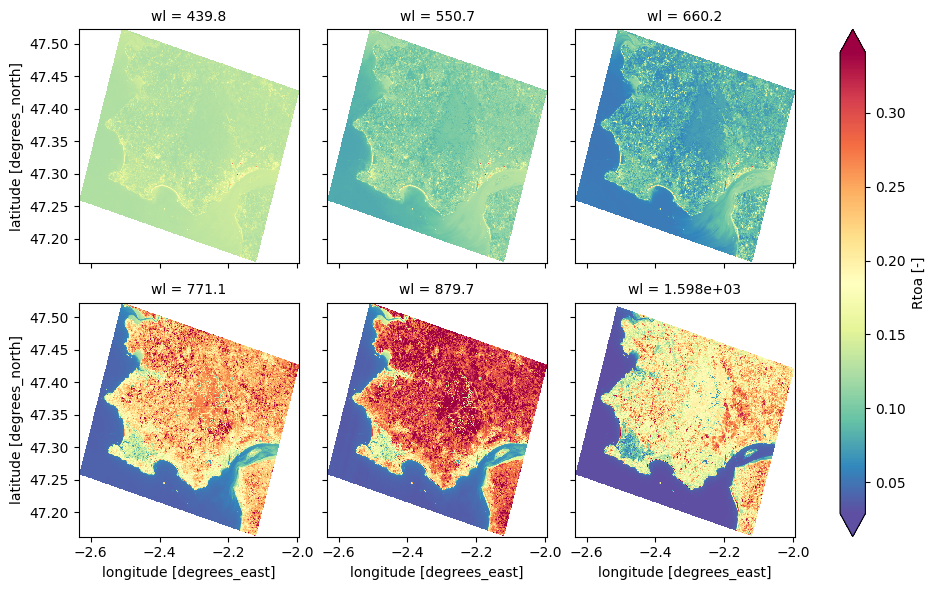

In [5]:

fig = l1c_prod.Rtoa.sel(wl=[440,550,660,770,880,1600], method='nearest').rio.reproject(4326).plot.imshow(
    col='wl', col_wrap=3, cmap=plt.cm.Spectral_r, robust=True
)
#plt.savefig(root_path+'figure_rtoa.jpg', format='jpg', dpi=300)
plt.show()

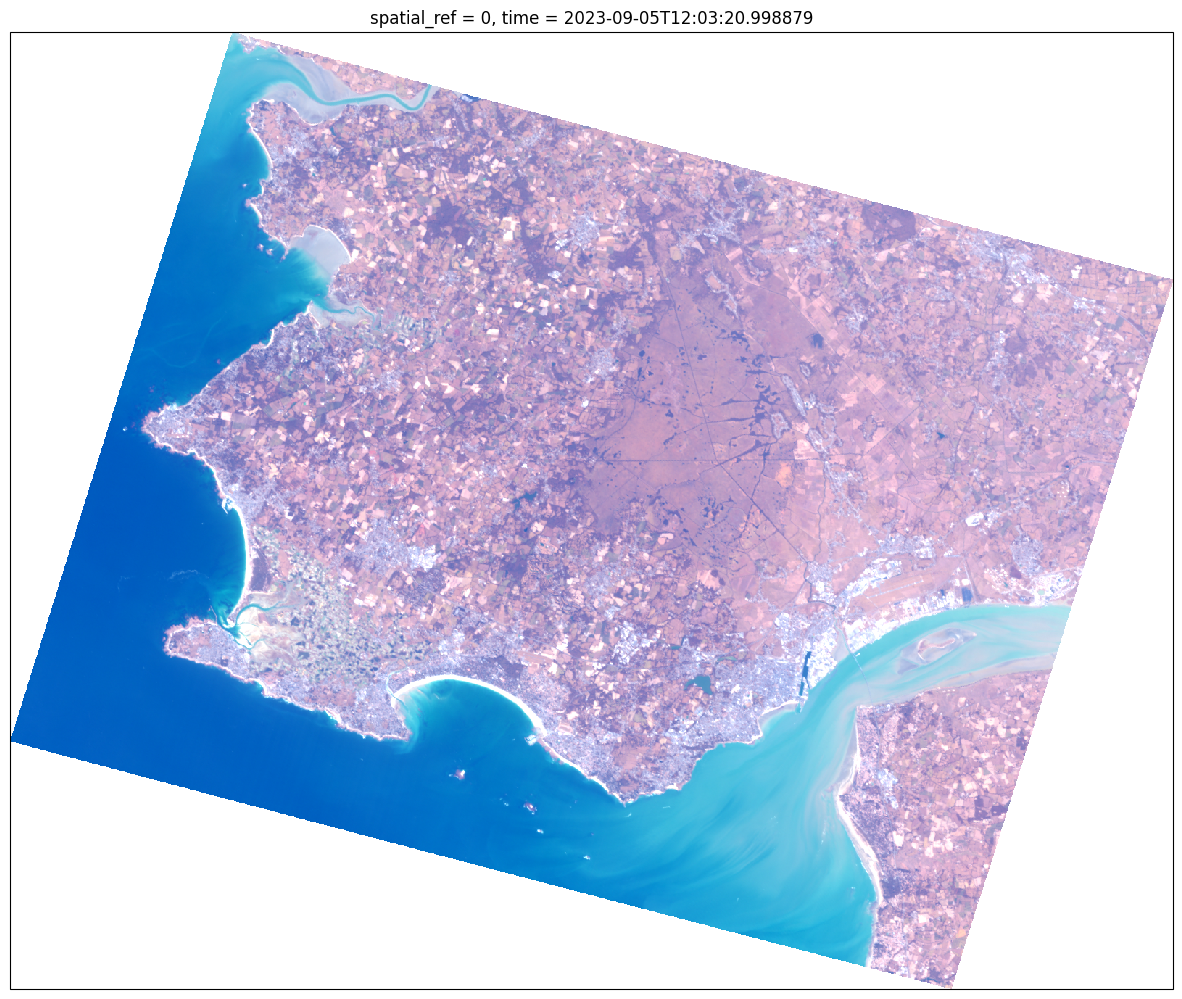

In [6]:
str_epsg = str(l1c_prod.rio.crs)
crs = l1c_prod.rio.crs
zone = str_epsg[-2:]
is_south = str_epsg[2] == 7
proj = ccrs.UTM(zone, is_south)

coarsening=1
gamma=0.2
brightness_factor = 1
plt.figure(figsize=(15,15))
fig = (l1c_prod.Rtoa[:, ::coarsening, ::coarsening].sel(wl=[705,560,460],method='nearest')**gamma*brightness_factor).plot.imshow(rgb='wl',robust=True, subplot_kws=dict(projection= proj))
fig.axes.set(xticks=[], yticks=[])
fig.axes.set_ylabel('')
fig.axes.set_xlabel('')
fig

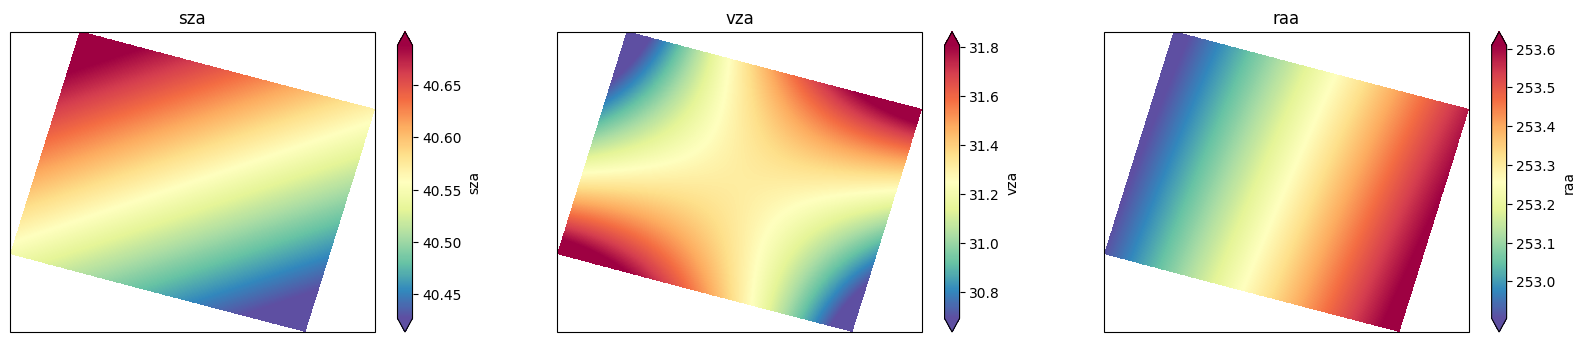

In [7]:
params=['sza','vza','raa']

fig,axs = plt.subplots(1,3,figsize=(20,5),subplot_kw=dict(projection= proj))
axs=axs.ravel()

for i in range(len(params)):
    l1c_prod[params[i]].plot.imshow(cmap=plt.cm.Spectral_r, robust=True,
                               cbar_kwargs={'shrink': 0.78,'label':params[i]},ax=axs[i]) # extent=extent_val, transform=proj, 
      
    axs[i].set_title(params[i])    

In [8]:
import logging

lut_file='/DATA/git/satellite_app/hgrs/data/lut/opac_osoaa_lut_v3_light.nc'
lut_file='/data/vrtc/xlut/toa_lut_opac_wind_up_v3.nc'

aero_lut = xr.open_dataset(lut_file).isel(wind=1).drop_sel(model='URBA_rh70').squeeze()
aero_lut['wl'] = aero_lut['wl'] * 1000

date = l1c_prod.time

# -----------------------------------------
# Create hGRS object
# -----------------------------------------
logging.info('Create hGRS object')
prod = hgrs.Algo(l1c_prod, expon=1.5, xcoarsen=20, ycoarsen=20)
prod.round_angles()

# -----------------------------------------
# get CAMS and set atmospheric parameters
# -----------------------------------------
logging.info('get CAMS and set atmospheric parameters')
# lazy loading
cams = xr.open_dataset(cams_path, decode_cf=True,
                       chunks={'time': 1, 'x': 500, 'y': 500})
# slicing
#
cams = cams.sel(latitude=clat, longitude=clon, method='nearest')
# fix for new ADS format (sept 2024)
if ('forecast_period' in cams.dims) & ('forecast_reference_time' in cams.dims):
    cams = cams.stack(time_buffer=['forecast_period', 'forecast_reference_time']).swap_dims(
        {'time_buffer': 'valid_time'}).sortby('valid_time').rename(
        {'valid_time': 'time'}).drop_vars(['time_buffer'])

cams = cams.sel(time=date, method='nearest')

# select OPAC aerosol model
# aod = cams[['aod355', 'aod380', 'aod400', 'aod440', 'aod469', 'aod500', 'aod550', 'aod645', 'aod670',
#            'aod800', 'aod865', 'aod1020', 'aod1064', 'aod1240', 'aod1640', 'aod2130']].to_pandas()
# aod.index = aod.index.str.replace('aod', '').astype(int)
# cams_aod = aod.to_xarray().rename({'index': 'wl'})
cams_wls = [469, 550, 670, 865, 1240]
param_aod = []
for wl in cams_wls:
    wl_ = str(wl)
    param_aod.append('aod' + wl_)

cams_aod = cams[param_aod].to_array(dim='wl')

wl_cams = cams_aod.wl.str.replace('aod', '').astype(float)
cams_aod = cams_aod.assign_coords(wl=wl_cams)

INFO:root:Create hGRS object
INFO:root:get CAMS and set atmospheric parameters


In [9]:
rh = '_rh70'
models = ['COAV' + rh, 'COPO' + rh, 'DESE' + rh, 'MACL' + rh, 'MAPO' + rh,       ]  # 'ANTA' + rh, 'ARCT' + rh,'URBA' + rh
#lut_aod = aero_lut.aot.sel(model=models, aot_ref=1).interp(wl=cams_aod.wl)
#idx = np.abs((cams_aod / cams.aod550) - lut_aod).sum('wl').argmin()
#opac_model = aero_lut.sel(model=models).model.values[idx]

# new LUT:

lut_aod = aero_lut.aot.sel(aot_ref=1).interp(wl=cams_aod.wl)
idx = np.abs((cams_aod / cams.aod550) - lut_aod).sum('wl').argmin()
opac_model = aero_lut.model.values[idx]
print(opac_model)

# set gases and pressure
prod.pressure = float(cams.sp) * 1e-2
prod.to3c = float(cams.gtco3)
prod.tno2c = float(cams.tcno2)
prod.tch4c = float(cams.tc_ch4)

MACL_rh70


In [10]:
opac_model

'MACL_rh70'

In [11]:
# -----------------------------------------
# Apply water masking
# -----------------------------------------
logging.info('Apply water masking')
prod.apply_water_masks()

# -----------------------------------------
# Construct coarse resolution raster
# -----------------------------------------
logging.info('Construct coarse resolution raster')
prod.get_coarse_masked_raster()
# prod.plot_water_pix_number()

# -----------------------------------------
# Correct for gaseous absorption
# -----------------------------------------
logging.info('Correct for gaseous absorption')
prod.get_gaseous_transmittance()
prod.other_gas_correction()

INFO:root:Apply water masking
INFO:root:Construct coarse resolution raster
INFO:root:Correct for gaseous absorption


In [12]:
aero_lut

<xarray.Dataset> Size: 447MB
Dimensions:            (model: 5, aot_ref: 10, wl: 10, sza: 45, vza: 34, azi: 73)
Coordinates:
  * wl                 (wl) float32 40B 350.0 400.0 500.0 ... 2.2e+03 2.5e+03
  * aot_ref            (aot_ref) float32 40B 0.0 0.001 0.01 0.1 ... 0.7 1.0 1.5
  * sza                (sza) float32 180B 0.0 2.0 4.0 6.0 ... 84.0 86.0 88.0
    wind               float64 8B 2.0
  * vza                (vza) float32 136B 0.0 1.14 2.62 ... 45.93 47.43 48.92
  * azi                (azi) float32 292B 0.0 5.0 10.0 ... 350.0 355.0 360.0
  * model              (model) <U9 180B 'ARCT_rh70' 'COAV_rh70' ... 'WASO_rh0'
Data variables: (12/13)
    wl_ref             (model, aot_ref, wl) float32 2kB ...
    Cext_ref           (model, aot_ref, wl) float32 2kB ...
    ssa_ref            (model, aot_ref, wl) float32 2kB ...
    aot                (model, aot_ref, wl) float32 2kB ...
    Cext               (model, aot_ref, wl) float32 2kB ...
    ssa                (model, aot_ref, wl) float32 2kB ...
    ...                 ...
    bbp_ratio          (model, aot_ref, wl) float32 2kB ...
    bup_ratio          (model, aot_ref, wl) float32 2kB ...
    vol_mean_particle  (model, aot_ref, wl) float32 2kB ...
    nr                 (model, aot_ref, wl) float32 2kB ...
    Ed                 (model, aot_ref, wl, sza) float32 90kB ...
    I                  (model, aot_ref, wl, sza, vza, azi) float64 447MB ...

In [13]:
spectral = hgrs.Spectral(prod.wl,prod.fwhm,expon=1.83)
Tg_hyp = np.exp(- prod.air_mass_mean * prod.abs_gas_opt_thick)
Tg = spectral.convolve2(np.exp(- prod.air_mass_mean * prod.abs_gas_opt_thick),name='Tg')

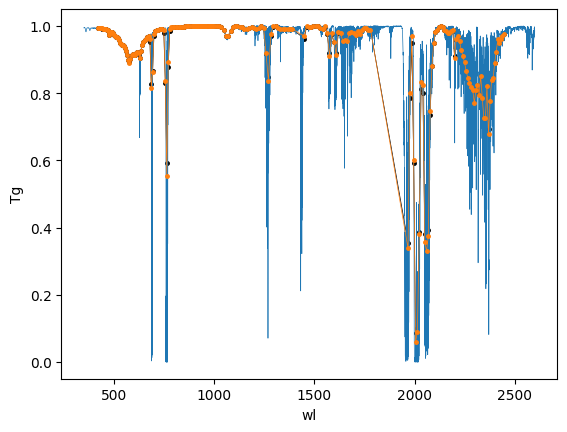

In [14]:
prod.Tg_other.plot(color='k',marker='o',ms=2.5,lw=0.5)
Tg_hyp.plot(lw=0.5)
Tg.plot(marker='o',ms=2.5,lw=0.5)

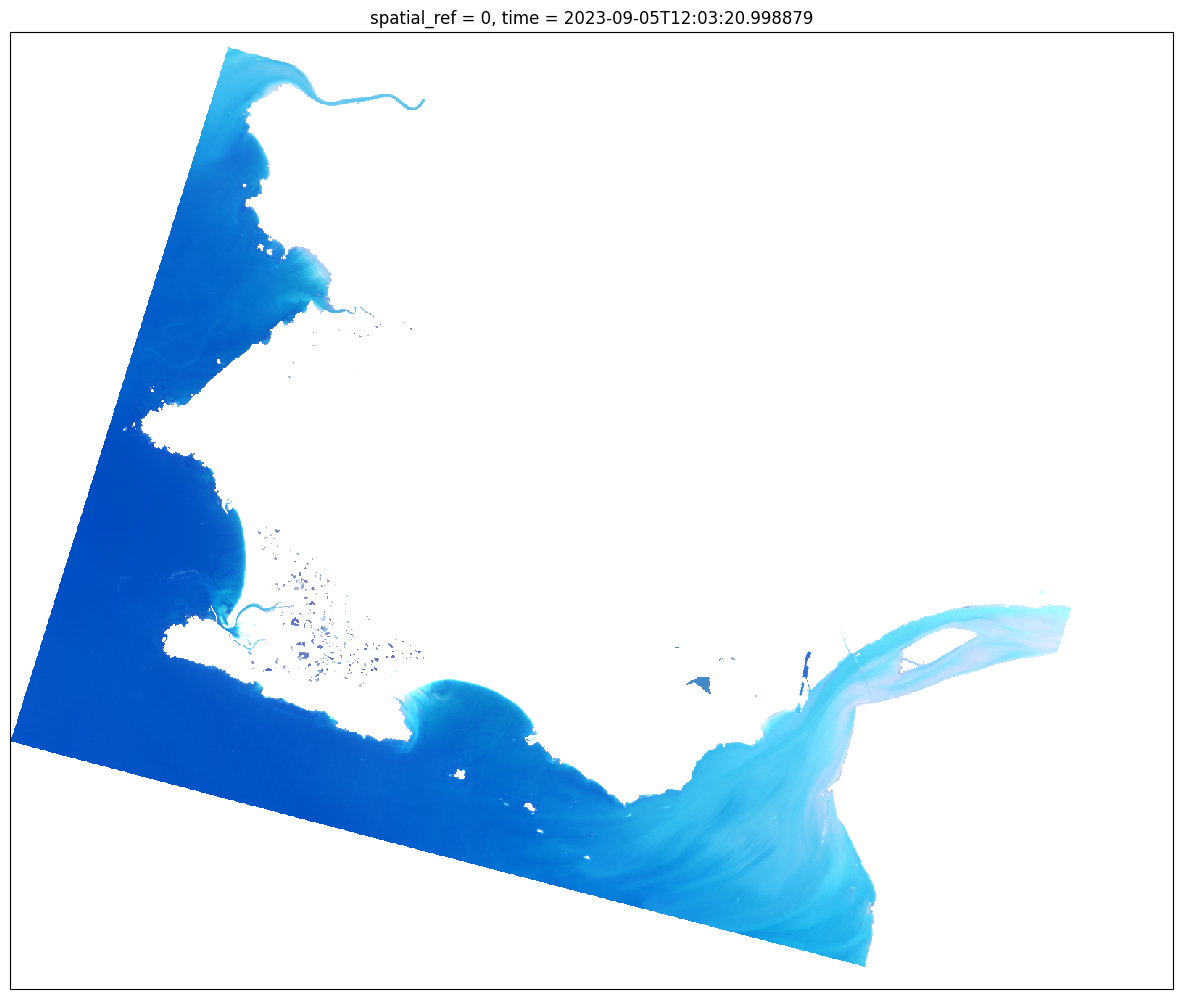

In [15]:
plt.figure(figsize=(15,15))
prod.raster.Rtoa[:, ::coarsening, ::coarsening].sel(wl=[705,560,460],method='nearest').plot.imshow(rgb='wl',robust=True, subplot_kws=dict(projection= proj))

In [16]:
logging.info('water vapor retrieval and correction')
wv_retrieval = hgrs.WaterVapor(prod)
wv_retrieval.solve()

INFO:root:water vapor retrieval and correction


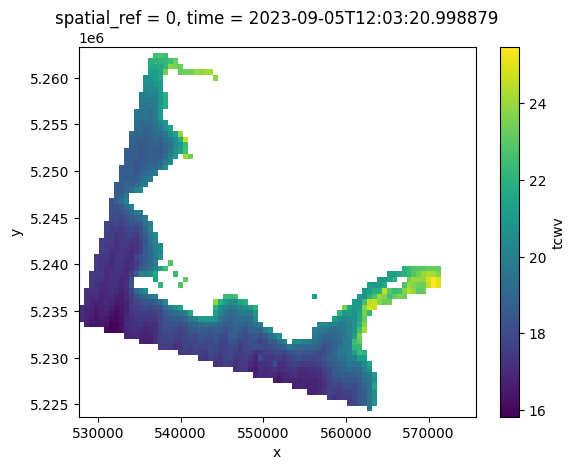

In [17]:
wv_retrieval.water_vapor.tcwv.plot.imshow()

In [18]:
prod.get_wv_transmittance_raster(wv_retrieval.water_vapor)
prod.water_vapor_correction()

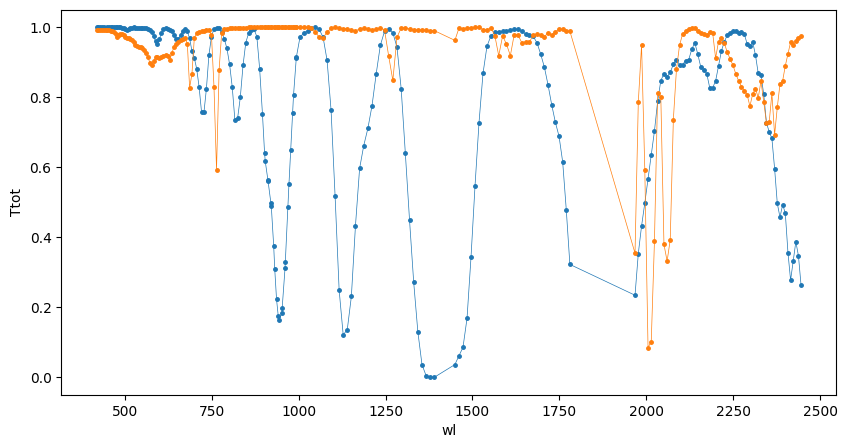

In [19]:
plt.figure(figsize=(10,5))
prod.Twv_raster.mean(['x','y']).plot(marker='o',ms=2.5,lw=0.5)
prod.Tg_other.plot(marker='o',ms=2.5,lw=0.5)

In [49]:
aot550_min

0.05579824885057788

In [ ]:
# ------------------------------------------
# aerosol retrieval
# ------------------------------------------
logging.info('aerosol retrieval')

variable = 'Rtoa'
prod.coarse_masked_raster = prod.remove_wl_dataset(
    prod.coarse_masked_raster, prod.wl_to_remove, variable=variable)

# TODO double check regularization from CAMS AOT values
aod550_mean = cams.aod550.mean().values

aod550_std = cams.aod550.std().values
aod550_std = np.max([aod550_std, 0.2 * aod550_mean+0.05])
aot550_min = 0.002# np.max([aod550_mean - 2*aod550_std,0.001])
aero_retrieval = hgrs.Aerosol(prod,
                              aerosol_model=opac_model,
                              first_guess=[aod550_mean, 0.],
                              aot550_limits=[aot550_min,
                                             aod550_mean + aod550_std])
aero_retrieval.solve()
self = aero_retrieval
self.prepare_lut(prod.coarse_masked_raster.wl)
self.smoothing()

#self.aero_img['aot_ref_smoothed']=self.aero_img['aot_ref_smoothed']*0.5
# construct aot raster
# with full res
#aot_ref_vals = self.aot_ref_full.round(3)
# with coarse res
aot_ref_vals = self.aero_img['aot_ref_smoothed'].round(3)
aot_refs = np.unique(aot_ref_vals)
aot_refs = aot_refs[~np.isnan(aot_refs)]
# TODO update LUT for aot< 0.001
aot_refs[aot_refs<0.002]=0.002
# if rounded aot_ref has unique value
if len(aot_refs) == 1:
    aot_refs = np.concatenate([ aot_refs, 1.2 * aot_refs])
aots = self.aot_lut.interp(aot_ref=aot_refs, method='linear')
aots = aots.interp(aot_ref=aot_ref_vals, method='nearest')

aots.name = 'aot'
aots.attrs['description'] = 'spectral aerosol optical thickness'

# construct raster for diffuse atmospheric reflectance
Rdiffs = self.Rtoa_lut.interp(aot_ref=aot_refs, method='linear')
Rdiffs = Rdiffs.interp(aot_ref=aot_ref_vals, method='nearest')
Rdiffs.name = 'Rtoa_diff'
Rdiffs.attrs['description'] = 'top-of-atmosphere atmosphere reflectance'



# construct raster for direct transmittance due to rayleigh and aerosol
Tdirs = self.transmittance_dir(aots, self.air_mass, rot=self.rot)
Tdirs.name = 'Tdir'
Tdirs.attrs['description'] = 'direct transmittance due to rayleigh and aerosol for total air mass'


aero_retrieval.get_atmo_parameters(prod.coarse_masked_raster.wl)

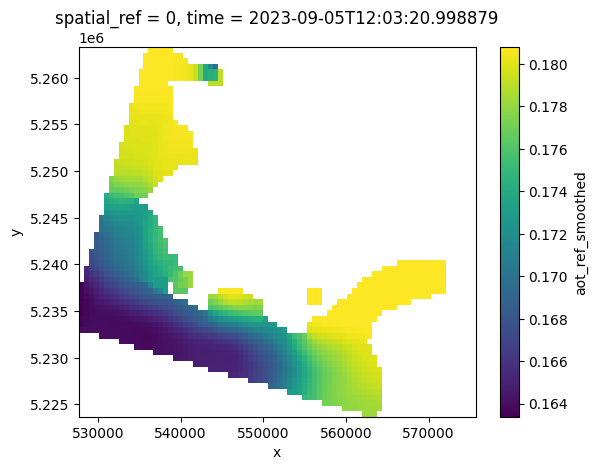

In [39]:
#self.aero_img['aot_ref_smoothed']=self.aero_img['aot_ref_smoothed']*0.5
self.aero_img.aot_ref_smoothed.plot.imshow()

In [33]:
# ------------------------------------------
# full resolution processing
# ------------------------------------------
logging.info('process full resolution')

prod.raster = prod.remove_wl_dataset(prod.raster, prod.wl_to_remove)
prod.other_gas_correction(raster_name='raster', variable='Rtoa')

INFO:root:process full resolution


raster raster.Rtoa is already corrected for other gases transmittance
set attribute other_gas_correction to False to proceed anyway


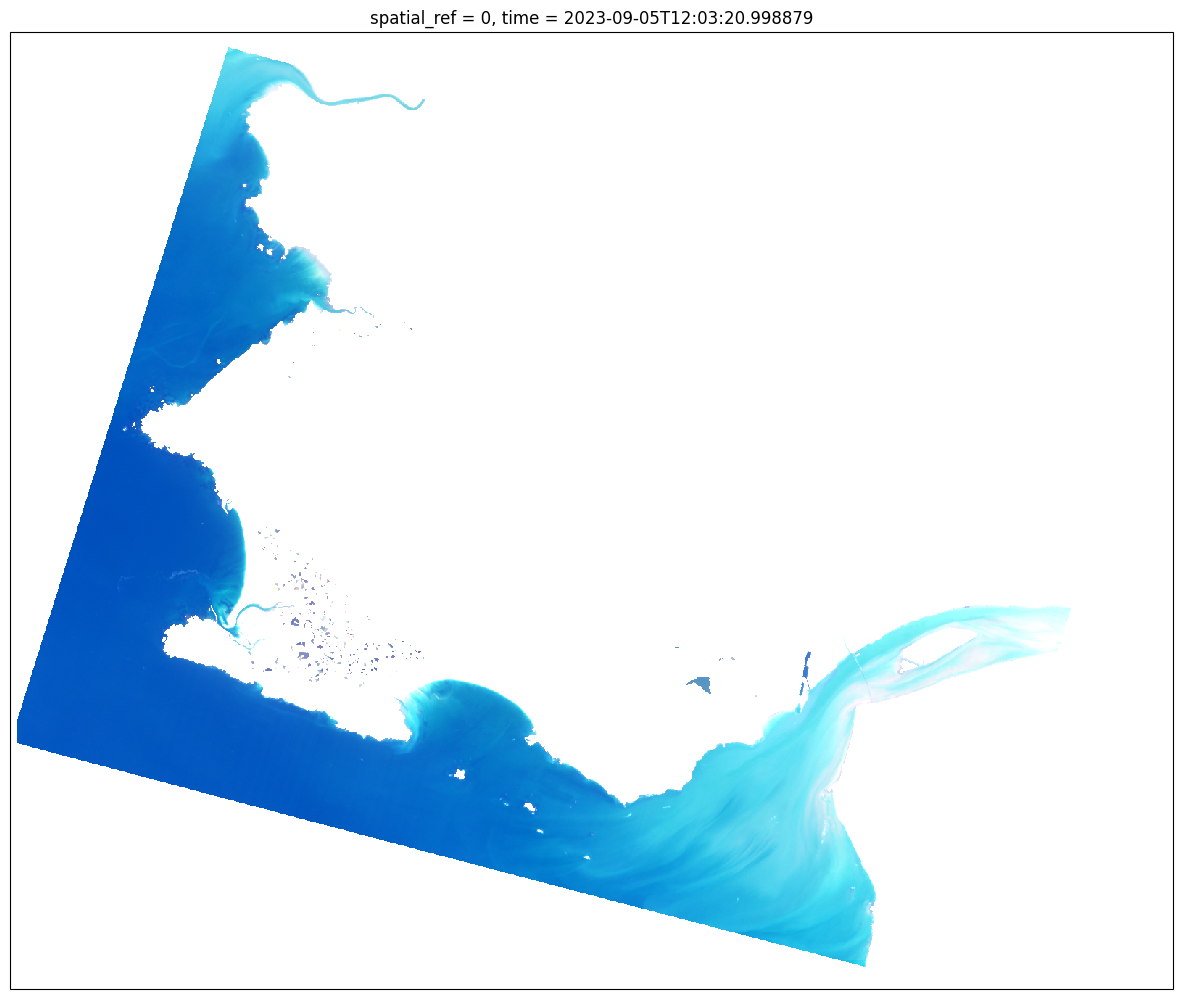

In [34]:
plt.figure(figsize=(15,15))
prod.raster.Rtoa[:, ::coarsening, ::coarsening].sel(wl=[705,560,460],method='nearest').plot.imshow(rgb='wl',robust=True, subplot_kws=dict(projection= proj))

In [35]:
#wv_full = prod.get_full_resolution(wv_retrieval.water_vapor)
#prod.get_wv_transmittance_raster(wv_retrieval.water_vapor)
#prod.water_vapor_correction(raster_name='raster', variable='Rtoa')

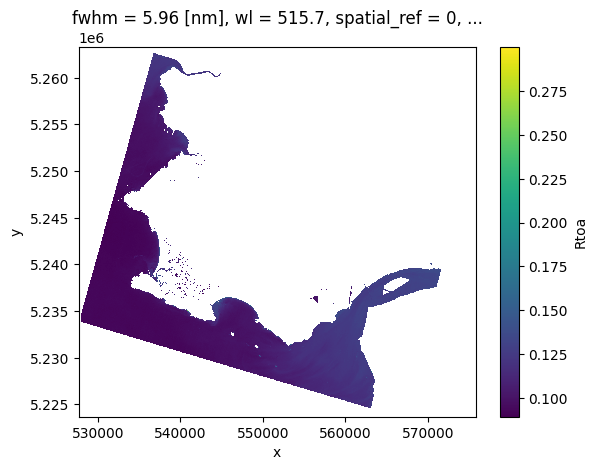

In [36]:
prod.raster.Rtoa.isel(wl=20).plot.imshow()

In [ ]:
# ------------------------------------------
# full resolution processing
# ------------------------------------------
chunk = 256
height, width, Nwl = len(prod.raster.y), len(prod.raster.x), len(prod.raster.wl)
results = np.full((height, width), 0, dtype=np.float32)
variable = 'Rtoa'
for iy in range(0, height, chunk):
    yc = min(height, iy + chunk)
    if yc == height:
        continue
    for ix in range(0, width, chunk):
        xc = min(width, ix + chunk)
        if xc == width:
            continue
        raster = prod.raster[variable][:, iy:yc, ix:xc]
        Twv_raster = prod.Twv_raster.interp(x=raster.x,y=raster.y)
        prod.raster[variable].data[:, iy:yc, ix:xc] = raster /  Twv_raster
       

Rdiff_full = aero_retrieval.atmo_img.Rtoa_diff  # .interp(x=prod.raster.x, y=prod.raster.y)
Tdir_full = aero_retrieval.atmo_img.Tdir  # .interp(x=prod.raster.x, y=prod.raster.y)
wl_sunglint = prod.wl_sunglint
    
Rrs = np.full((Nwl,height, width), np.nan, dtype=np.float32)
BRDF_sunglint = np.full((height, width), np.nan, dtype=np.float32)

for iy in range(0, height, chunk):
    yc = min(height, iy + chunk)
    if yc == height:
        continue
    for ix in range(0, width, chunk):
        xc = min(width, ix + chunk)
        if xc == width:
            continue
            
        Rcorr = prod.raster.Rtoa[:, iy:yc, ix:xc] 
        Rdiff_full_=Rdiff_full.interp(x=Rcorr.x, y=Rcorr.y)
        Rcorr = Rcorr - Rdiff_full_
        
        Tdir_full_=Tdir_full.interp(x=Rcorr.x, y=Rcorr.y)        

        sunglint_eps = aero_retrieval.sunglint_eps
        BRDF_sunglint[iy:yc, ix:xc]  = (Rcorr.sel(wl=wl_sunglint) / (Tdir_full_.sel(wl=wl_sunglint)
                                                      * sunglint_eps.sel(wl=wl_sunglint))).mean(dim='wl')
        
        # TODO clean up xarray inheritance of some extra coordinates...
        # BRDF_sunglint = BRDF_sunglint.drop_vars('aot_ref', errors=False).squeeze()
        Rdir = Tdir_full_ * sunglint_eps * BRDF_sunglint[iy:yc, ix:xc] 
        
        Rrs[:,iy:yc, ix:xc]  = (Rcorr - Rdir) / np.pi

l2_prod = xr.Dataset(dict(Rrs=(["wl", "y", "x"], Rrs),
                          brdfg_full=(["y", "x"], BRDF_sunglint), ),
                               coords=dict(x=prod.raster.x,
                                           y=prod.raster.y,
                                           wl=prod.raster.wl),
                               )


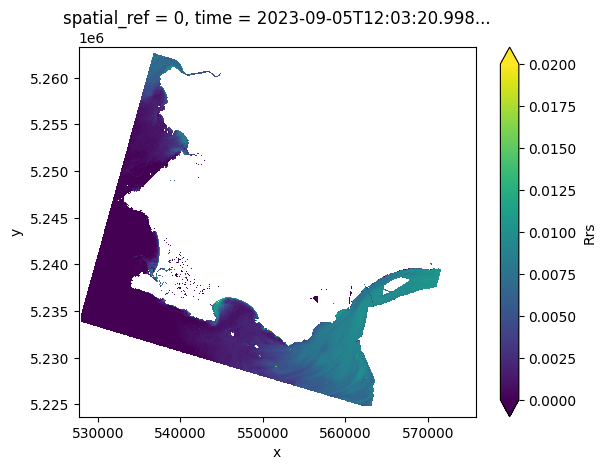

In [43]:
l2_prod.Rrs.isel(wl=20).plot.imshow(vmin=0,vmax=0.02)

In [ ]:
# finally correct for down and upward transmittances
# TODO compute pixel wise
Ttot_Ed = xr.open_dataset('/DATA/git/satellite_app/hgrs/data/lut/transmittance_downward_irradiance.nc')
aot_ref = float(aero_retrieval.aero_img.aot_ref.mean())
wl = l2_prod.Rrs.wl.values
sza = float(aero_retrieval.sza)
vza = float(aero_retrieval.vza)
Ttot_Ed_ = Ttot_Ed.Ttot_Ed.sel(model=opac_model).interp(sza=sza, method='cubic'
                                                        ).interp(aot_ref=aot_ref, method='quadratic').interp(
    wl=wl, method='cubic')
Ttot_Lu_ = Ttot_Ed.Ttot_Ed.sel(model=opac_model).interp(sza=vza, method='cubic'
                                                        ).interp(aot_ref=aot_ref, method='quadratic').interp(
    wl=wl, method='cubic') ** 1.05
Ttot = (Ttot_Ed_ * Ttot_Lu_).reset_coords(drop=True)
l2_prod['Rrs'] = l2_prod.Rrs / Ttot


# -----------------------------
# construct output image
# -----------------------------
logging.info('construct final product')

# -----------------------------
# data
wv = wv_retrieval.water_vapor.rename({"x": "xc", "y": "yc"})
aero = aero_retrieval.aero_img.rename({"x": "xc", "y": "yc"})
water_pixel_prop = (prod.coarse_masked_raster.water_pixel_number / prod.Npix_per_megapix).drop_vars(
    'tcwv').rename({"x": "xc", "y": "yc"})
water_pixel_prop.name = 'water_pix_prop'
#geom = prod.raster[['lon', 'lat']].drop_vars('tcwv')
#Rrs_ = Rrs_l2.reset_coords().drop_vars(['model', 'z']).rename({'tcwv': 'tcwv_full', 'aot_ref': 'aot_ref_full'}).set_coords(['time','spatial_ref'])
l2_prod = xr.merge([l2_prod, wv, aero,water_pixel_prop])
#l2_prod['brdfg_full'] = BRDF_sunglint



param = 'Rrs'
l2_prod[param].attrs['unit'] = 'per steradian'
l2_prod[param].attrs['long_name'] = 'Remote sensing reflectance'
l2_prod[param].attrs['description'] = 'Directional water-leaving radiance normalized ' + \
                                      'by downwelling irradiance in the observation geometry'

param = 'water_pix_prop'
l2_prod[param].attrs['unit'] = '-'
l2_prod[param].attrs['description'] = 'Relative number of water pixel within mega-pixel used for inversion'

param = 'brdfg'
l2_prod[param].attrs['unit'] = '-'
l2_prod[param].attrs['long_name'] = 'BRDF_sunglint'
l2_prod[param].attrs['description'] = 'Bidirectional reflectance distribution function ' + \
                                      'estimated from the sunglint in the SWIR for the observation geometry'
param = 'brdfg_std'
l2_prod[param].attrs['unit'] = '-'
l2_prod[param].attrs['long_name'] = 'BRDF_sunglint_standard deviation'
l2_prod[param].attrs['description'] = 'Uncertainty based on optimal estimation procedure'
param = 'brdfg_full'
l2_prod[param].attrs['unit'] = '-'
l2_prod[param].attrs['long_name'] = 'BRDF_sunglint'
l2_prod[param].attrs['description'] = 'Bidirectional reflectance distribution function ' + \
                                      'estimated from the sunglint in the SWIR for the observation geometry'

param = 'aot_ref'
l2_prod[param].attrs['unit'] = '-'
l2_prod[param].attrs['long_name'] = 'aerosol_optical_thickness'
l2_prod[param].attrs['description'] = 'Aerosol optical thickness at the reference wavelength (550nm)'
param = 'aot_ref_std'
l2_prod[param].attrs['unit'] = '-'
l2_prod[param].attrs['long_name'] = 'aerosol_optical_thickness_standard_deviation'
l2_prod[param].attrs['description'] = 'Uncertainty based on optimal estimation procedure'
#param = 'aot_ref_full'
#l2_prod[param].attrs['unit'] = '-'
#l2_prod[param].attrs['long_name'] = 'aerosol_optical_thickness'
#l2_prod[param].attrs['description'] = 'Aerosol optical thickness at the reference wavelength (550nm)'

param = 'tcwv'
l2_prod[param].attrs['unit'] = 'kg m-2'
l2_prod[param].attrs['long_name'] = 'total_columnar_water_vapor'
l2_prod[param].attrs['description'] = 'Water vapor integrated over the atmospheric layer'
param = 'tcwv_std'
l2_prod[param].attrs['unit'] = 'kg m-2'
l2_prod[param].attrs['long_name'] = 'total_columnar_water_vapor_standard_deviation'
l2_prod[param].attrs['description'] = 'Uncertainty based on optimal estimation procedure'
#param = 'tcwv_full'
#l2_prod[param].attrs['unit'] = 'kg m-2'
#l2_prod[param].attrs['long_name'] = 'total_columnar_water_vapor'
#l2_prod[param].attrs['description'] = 'Water vapor integrated over the atmospheric layer'

l2_prod['pressure'] = prod.pressure
l2_prod['pressure'].attrs['unit'] = 'hPa'
l2_prod['pressure'].attrs['description'] = 'Atmospheric pressure at the surface level'
l2_prod['pressure'].attrs['source'] = 'computed from CAMS and DEM (see DEM metadata)'

param = 'to3c'
l2_prod[param] = prod.__dict__[param]
l2_prod[param].attrs['unit'] = ''
l2_prod[param].attrs['description'] = 'Total columnar ozone concentration'
l2_prod[param].attrs['source'] = 'CAMS'

param = 'tno2c'
l2_prod[param] = prod.__dict__[param]
l2_prod[param].attrs['unit'] = ''
l2_prod[param].attrs['description'] = 'Total columnar Nitrogen dioxide concentration'
l2_prod[param].attrs['source'] = 'CAMS'

# -----------------------------
# --metadata
l2_prod.attrs = prod.raster.attrs
l2_prod.attrs['processing_date'] = str(dt.datetime.now())
l2_prod.attrs['acquisition_date'] =str(l2_prod.attrs['acquisition_date'])
l2_prod.attrs['hgrs_version'] = hgrs.__version__
l2_prod.attrs['description'] = 'PRISMA L2A-hGRS cube data'
l2_prod.attrs['DEM'] = 'not available'
l2_prod.attrs['aerosol_model'] = aero_retrieval.aerosol_model
keys = ['wl_water_vapor', 'wl_sunglint', 'wl_atmo', 'wl_to_remove', 'wl_green', 'wl_nir', 'wl_1600', 'wl_rgb',
        'xcoarsen', 'ycoarsen', 'Npix_per_megapix', 'block_size', 'pixel_percentage', 'pixel_threshold',
        'ang_resol', 'dirdata', 'abs_gas_file', 'lut_file', 'water_vapor_transmittance_file',
        'sunglint_threshold',
        'ndwi_threshold', 'green_swir_index_threshold', 'pressure', 'to3c', 'tno2c', 'tch4c', 'psl',
        'coef_abs_scat',
        'altitude']
for key in keys:
    l2_prod.attrs[key] = str(prod.__dict__[key])



def compute_scale_and_offset(array, nbit=16):
    max_, min_=np.nanmax(array),np.nanmin(array)
    # stretch/compress data to the available packed range
    scale_factor = (max_ - min_) / (2 ** nbit - 1)
    # translate the range to be symmetric about zero
    add_offset = min_ + 2 ** (nbit - 1) * scale_factor
    return scale_factor, add_offset

scale_factor, add_offset = compute_scale_and_offset(l2_prod.Rrs)

complevel = 5
encoding = {
            'Rrs': {'dtype': 'int16', 'scale_factor': scale_factor, 'add_offset': add_offset, '_FillValue': -32768, "zlib": True,
                    "complevel": complevel},
            'aot_ref_full': {'dtype': 'int16', 'scale_factor': 0.001, '_FillValue': -9999, "zlib": True,
                             "complevel": complevel},
            'aot_ref': {'dtype': 'int16', 'scale_factor': 0.001, '_FillValue': -9999, "zlib": True,
                        "complevel": complevel},
            'aot_ref_std': {'dtype': 'int16', 'scale_factor': 0.001, '_FillValue': -9999, "zlib": True,
                            "complevel": complevel},
            'brdfg_full': {'dtype': 'int16', 'scale_factor': 0.00001, 'add_offset': .2, '_FillValue': -32768,
                           "zlib": True, "complevel": complevel},
            'brdfg': {'dtype': 'int16', 'scale_factor': 0.00001, 'add_offset': .2, '_FillValue': -32768, "zlib": True,
                      "complevel": complevel},
            'brdfg_std': {'dtype': 'int16', 'scale_factor': 0.00001, 'add_offset': .2, '_FillValue': -32768,
                          "zlib": True, "complevel": complevel},
            'tcwv_full': {'dtype': 'int16', 'scale_factor': 0.01, '_FillValue': -9999, "zlib": True,
                          "complevel": complevel},
            'tcwv': {'dtype': 'int16', 'scale_factor': 0.01, '_FillValue': -9999, "zlib": True, "complevel": complevel},
            'tcwv_std': {'dtype': 'int16', 'scale_factor': 0.01, '_FillValue': -9999, "zlib": True,
                         "complevel": complevel}}

l2_prod.to_netcdf(l2a_path,encoding=encoding) # 

In [7]:
l2_prod = xr.open_dataset(l2a_path, decode_coords='all')
str_epsg = str(l2_prod.rio.crs)
crs = l2_prod.rio.crs
zone = str_epsg[-2:]
is_south = str_epsg[2] == 7
proj = ccrs.UTM(zone, is_south)

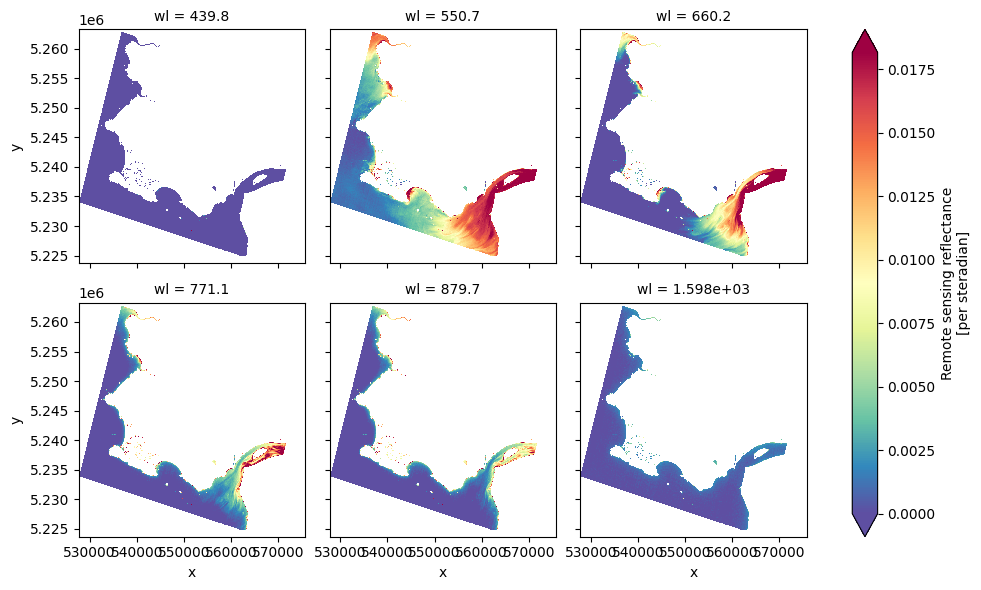

In [46]:
l2_prod.Rrs.sel(wl=[440,550,660,770,880,1600], method='nearest').plot.imshow(
    col='wl', col_wrap=3, cmap=plt.cm.Spectral_r,vmin=0, robust=True
)

In [47]:
import panel as pn

#hv.extension('bokeh')
pn.extension()
from grstbx import visual

v=visual.ViewSpectral(l2_prod.Rrs.isel(wl=range(0,93,5)) ,reproject=True)
print(v)
v.minmax=[0,0.1]
v.minmaxvalues=(0,0.04)
v.visu()

Column
    [0] WidgetBox
        [0] Markdown(str)
        [1] Column
            [0] Row
                [0] Markdown(str)
                [1] RadioButtonGroup(options=[0, 1, 2, 3, 4, ...], value=2)
            [1] Row
                [0] Row
                    [0] Markdown(str)
                    [1] DatePicker(enabled_dates=[datetime.date(2023, ...], start=datetime.date(2023, 9, 5), value=datetime.date(2023, 9, 5))
                [1] Row
                    [0] Markdown(str)
                    [1] Select(options=['CartoDark', ...], value='CartoDark')
            [2] Row
                [0] Row
                    [0] Markdown(str)
                    [1] EditableRangeSlider(end=0.1, name='Range Slider', step=0.0001, value=(0, 0.04), width=300)
                [1] Row
                    [0] Markdown(str)
                    [1] FloatSlider(name='Opacity', step=0.05, value=0.95)
                [2] Row
                    [0] Markdown(str)
                    [1] Select(options=['CET_D13', 'bky', ...], value='CET_D13')
        [2] HoloViews(Layout)

In [48]:
Twv =prod.Twv_raster.mean(['x','y']) #.plot(marker='o',ms=2.5,lw=0.5)

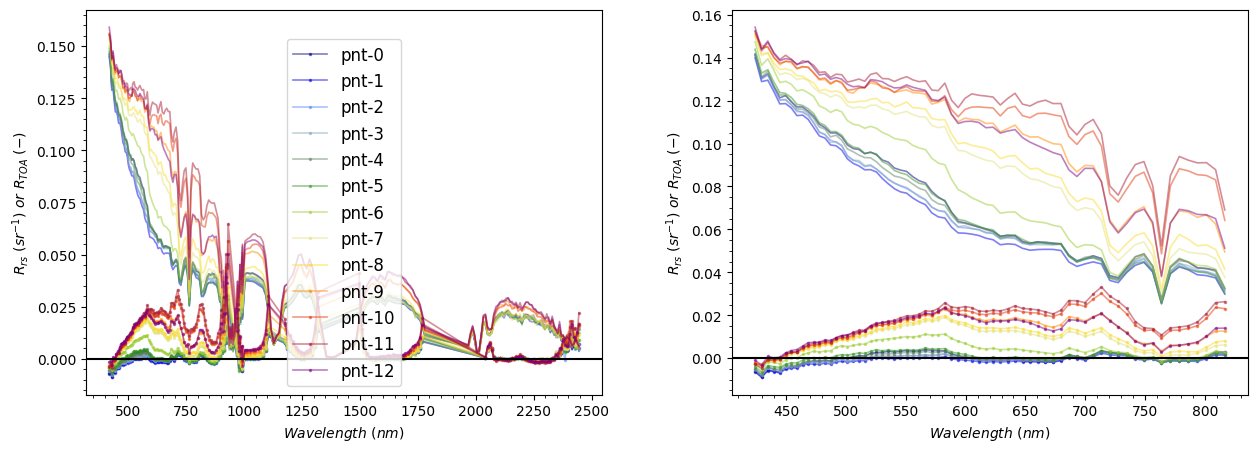

In [48]:
import geopandas as gpd

poi_stream = v.poi_stream
geom = poi_stream.data
geom=gpd.points_from_xy(geom['x'],geom['y'])#,crs="EPSG3857")index=[0], c
geom =gpd.GeoDataFrame(crs=3857, geometry=geom).to_crs(crs)
Ndata = len(geom)
cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     "grey",   'forestgreen','yellowgreen',
                                                     "khaki", "gold",
                                                     'orangered', "firebrick", 'purple'])
norm = mpl.colors.Normalize(vmin=0.0,vmax=Ndata-1)


wl_range=slice(420,820)
alpha=0.5
lw=1.2
ms=1.5

fig,axs = plt.subplots(1,2,figsize=(15,5))#,sharey=True)   
fig.subplots_adjust(hspace=0.05, wspace=0.25)
ax=axs[0]
indexes=np.dstack([geom.geometry.x,geom.geometry.y])[0]
for ii,index in enumerate(indexes):
    color=cmap(norm(ii))
   
   
    boa=l2_prod.Rrs.sel(x=index[0],y=index[1],method='nearest')
    
    boa.plot(label='pnt-'+str(ii),marker='o',ms=ms,lw=lw,c=color,alpha=alpha,ax=ax)
    
    boa.sel(wl=wl_range).plot(label='pnt-'+str(ii),marker='o',ms=ms,lw=lw,alpha=alpha,c=color,ax=axs[1])

    if True:
        toa=l1c_prod.Rtoa.sel(x=index[0],y=index[1],method='nearest')
        toa.plot(ms=ms,lw=lw,c=color,alpha=alpha,ax=ax)
        toa.sel(wl=wl_range).plot(ms=ms,lw=lw,c=color,alpha=alpha,ax=axs[1])
#(0.04*prod.Tg_other).plot(marker='o',ms=2.5,lw=0.5,ax=axs[0])
#(0.04*prod.Tg_other).sel(wl=wl_range).plot(marker='o',color='k',ms=2.5,lw=0.5,ax=axs[1])
#(0.04*Twv).plot(marker='o',ms=2.5,lw=0.5,ax=axs[0])
#(0.04*Twv).sel(wl=wl_range).plot(marker='o',color='b',ms=2.5,lw=0.5,ax=axs[1])

for ax in  axs:
    ax.set_ylabel(r'$R_{rs}\ (sr^{-1})\ or\ R_{TOA}\ (-)$')
    ax.axhline(0,color='k')
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.set_title('')
    ax.minorticks_on() 
    #prod.Twv_raster.mean(['x','y']).plot(marker='o',ms=2.5,lw=0.5)
   

axs[0].legend(fontsize=12)

In [11]:
l2_prod

<xarray.Dataset> Size: 3GB
Dimensions:           (wl: 192, x: 1434, y: 1171, yc: 58, xc: 71)
Coordinates:
  * wl                (wl) float64 2kB 418.4 424.0 429.5 ... 2.438e+03 2.445e+03
  * x                 (x) float64 11kB 6.314e+05 6.315e+05 ... 6.744e+05
  * y                 (y) float64 9kB 5.063e+06 5.063e+06 ... 5.028e+06
    spatial_ref       int64 8B 0
    time              datetime64[ns] 8B 2023-06-22T11:20:31.022526
  * xc                (xc) float64 568B 6.317e+05 6.323e+05 ... 6.737e+05
  * yc                (yc) float64 464B 5.063e+06 5.062e+06 ... 5.028e+06
Data variables: (12/19)
    fwhm              (wl) float64 2kB ...
    tcwv_full         (y, x) float64 13MB ...
    aot_ref_full      (y, x) float64 13MB ...
    vza               float64 8B ...
    azi               float64 8B ...
    sza               float64 8B ...
    ...                ...
    aot_ref_smoothed  (yc, xc) float64 33kB ...
    water_pix_prop    (yc, xc) float64 33kB ...
    brdfg_full        (y, x) float64 13MB ...
    pressure          float64 8B ...
    to3c              float64 8B ...
    tno2c             float64 8B ...
Attributes: (12/36)
    description:                     PRISMA L2A-hGRS cube data
    L1C_product_name:                ENMAP01-____L1C-DT0000023369_20230622T11...
    acquisition_date:                2023-06-22 11:20:31.022526
    processing_date:                 2025-07-10 15:04:12.612857
    hgrs_version:                    1.0.6
    DEM:                             not available
    ...                              ...
    to3c:                            0.007178874351366757
    tno2c:                           1.8731939211978936e-06
    tch4c:                           0.01030874088648272
    psl:                             1013
    coef_abs_scat:                   0.9
    altitude:                        0

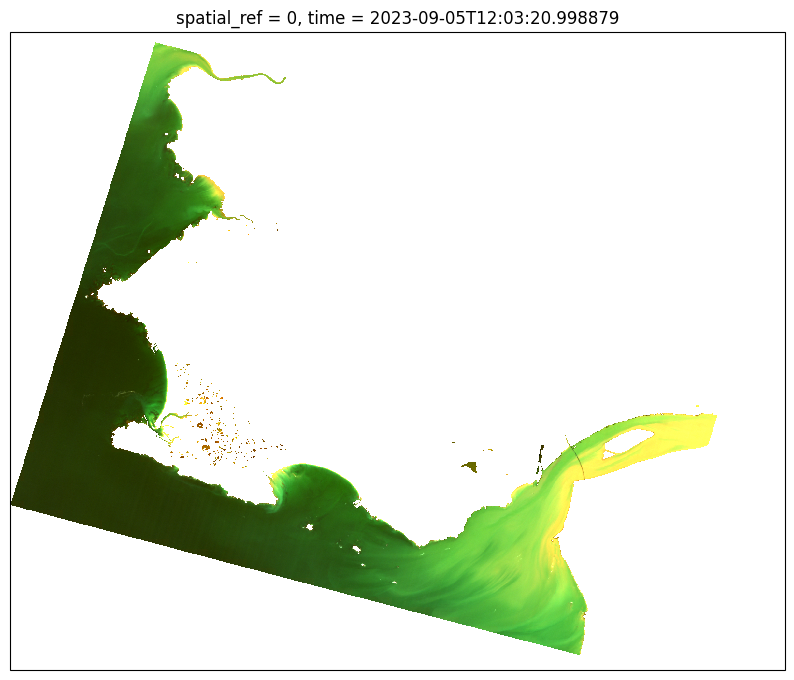

In [33]:
plt.figure(figsize=(10,10))
l2_prod.Rrs.sel(wl=[705,560,460],method='nearest').plot.imshow(rgb='wl',robust=True, subplot_kws=dict(projection= proj))

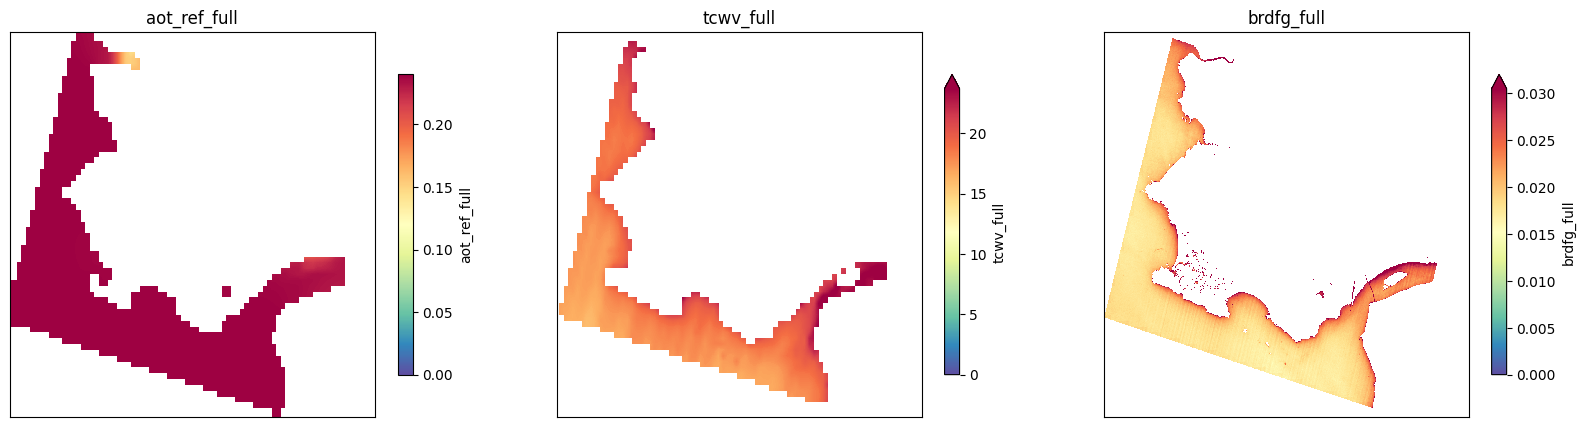

In [34]:
params=['aot_ref_full','tcwv_full','brdfg_full']

fig,axs = plt.subplots(1,3,figsize=(20,5))
axs=axs.ravel()

for i in range(len(params)):
    l2_prod[params[i]].plot.imshow(cmap=plt.cm.Spectral_r, robust=True,vmin=0,#vmax=0.201,
                               cbar_kwargs={'shrink': 0.78,'label':params[i]},ax=axs[i]) # extent=extent_val, transform=proj, 
    axs[i].set(xticks=[], yticks=[])
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')    
    axs[i].set_title(params[i])    

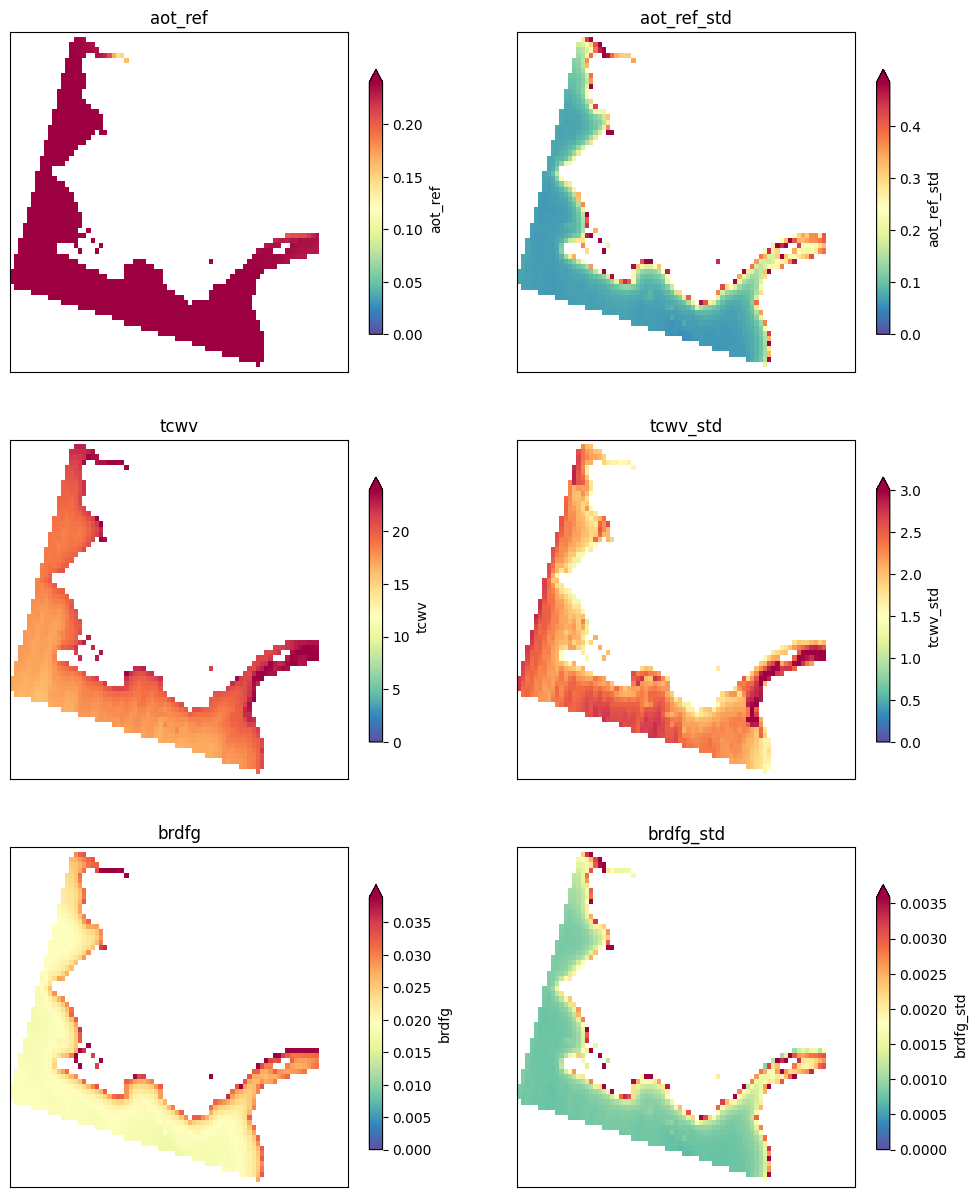

In [35]:
params=['aot_ref','aot_ref_std','tcwv','tcwv_std','brdfg','brdfg_std']

fig,axs = plt.subplots(3,2,figsize=(12,15))
axs=axs.ravel()

for i in range(len(params)):
    l2_prod[params[i]].plot.imshow(cmap=plt.cm.Spectral_r, robust=True,vmin=0,#vmax=0.201,
                               cbar_kwargs={'shrink': 0.78,'label':params[i]},ax=axs[i]) # extent=extent_val, transform=proj, 
    axs[i].set(xticks=[], yticks=[])
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')    
    axs[i].set_title(params[i])    

In [41]:
import GRSl2bgen
owt_process = GRSl2bgen.OWT_process(l2_prod)

owt_process.execute()

INFO:root:OWT classification
INFO:root:success
INFO:root:construct xarray owt product
INFO:root:OWT classification
INFO:root:success
INFO:root:construct xarray owt product


In [42]:
owt_process.output.owt_dist_Bi2024


<xarray.DataArray 'owt_dist_Bi2024' (y: 1171, x: 1434)> Size: 7MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * x            (x) float64 11kB 6.314e+05 6.315e+05 ... 6.744e+05 6.744e+05
    spatial_ref  int64 8B 0
    time         datetime64[ns] 8B 2023-06-22T11:20:31.022526
  * y            (y) float64 9kB 5.063e+06 5.063e+06 ... 5.028e+06 5.028e+06

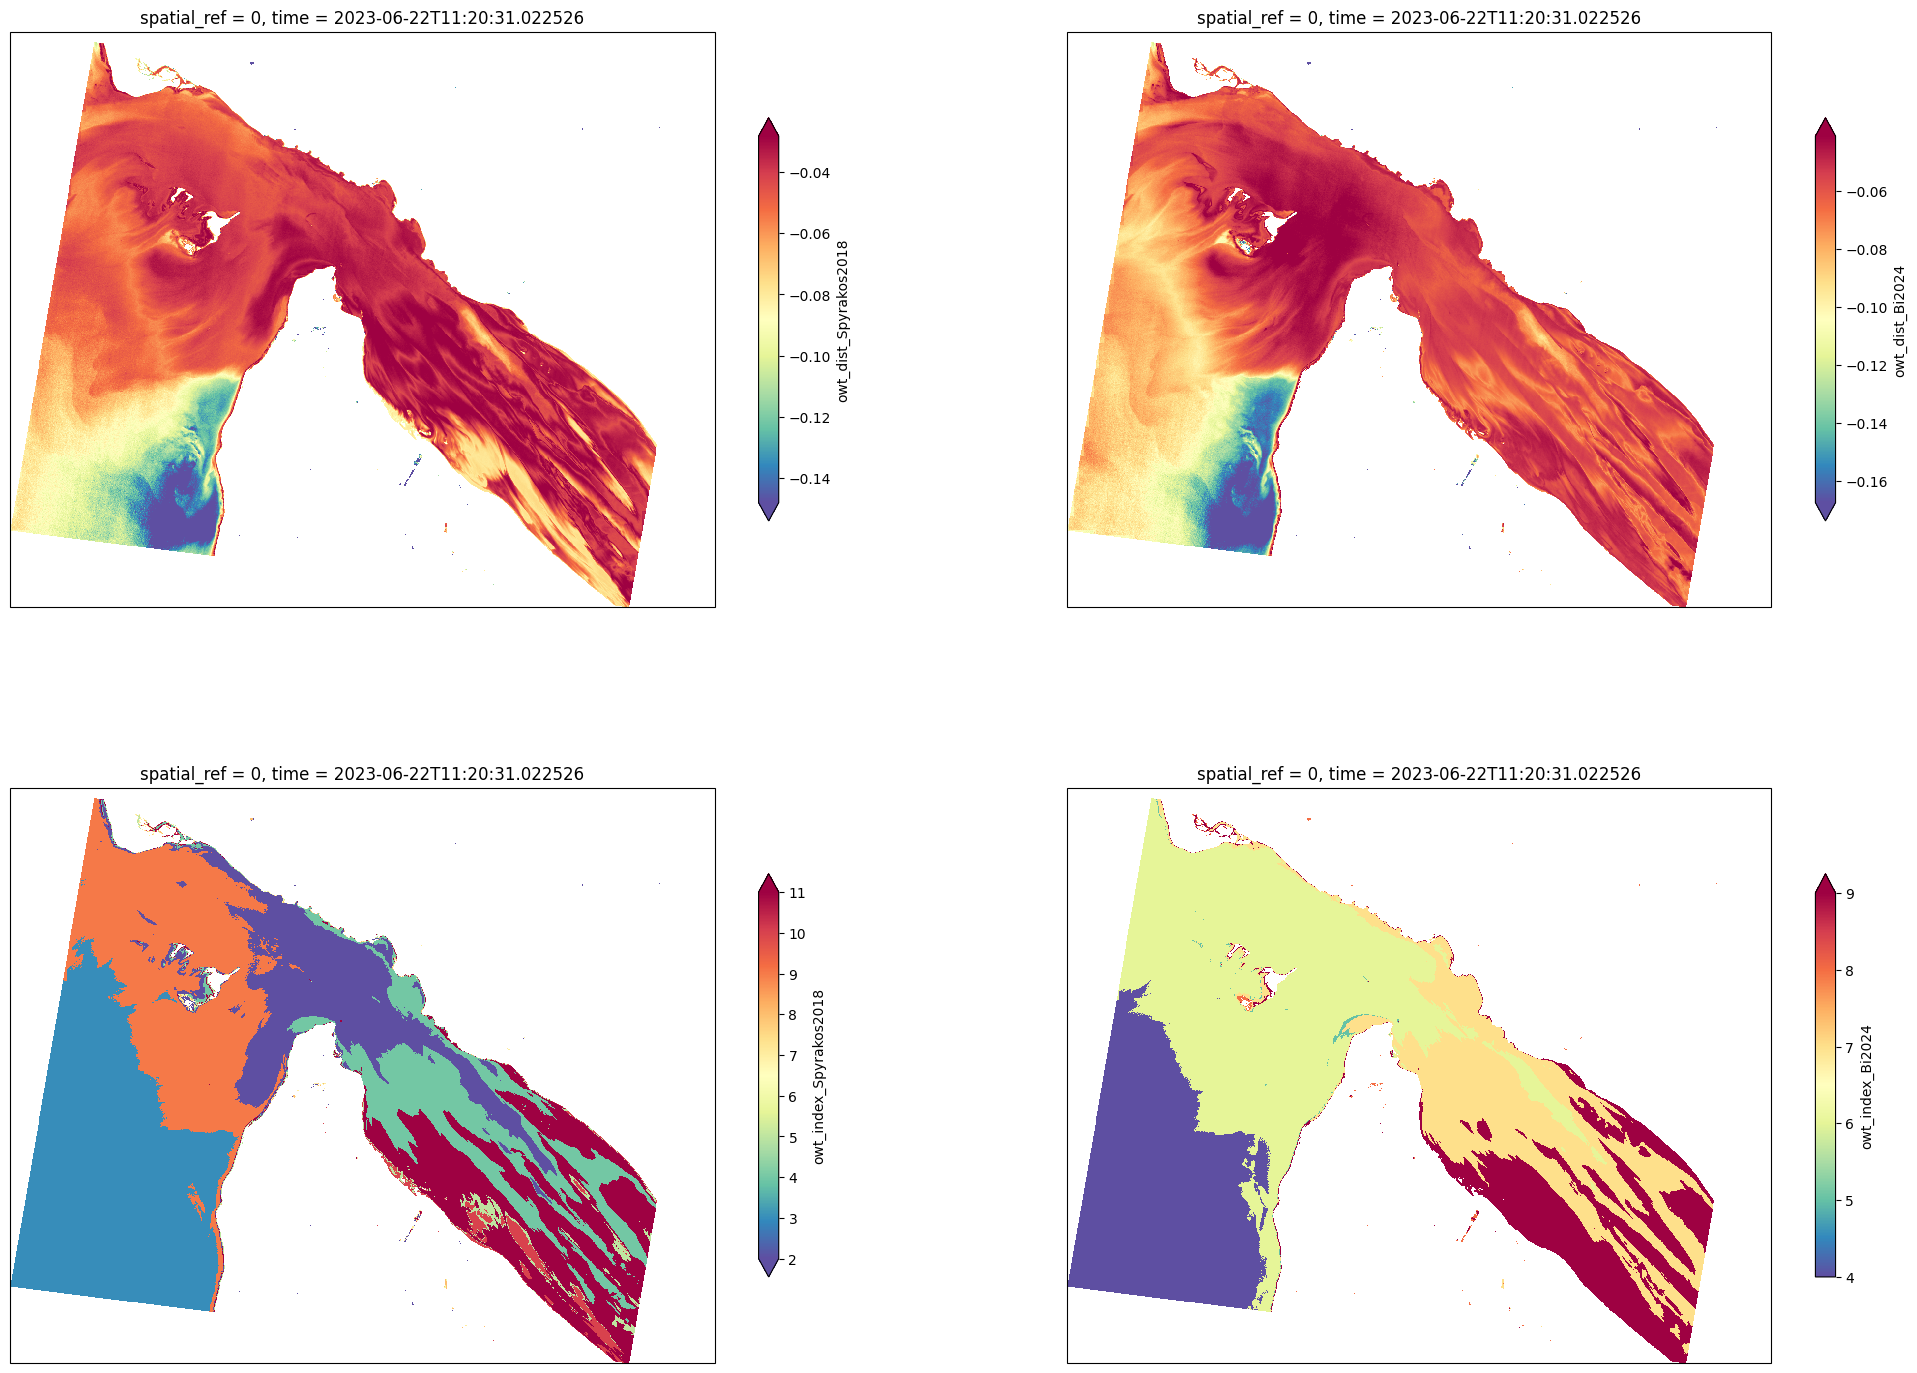

In [43]:


params = ['owt_dist_Spyrakos2018','owt_dist_Bi2024','owt_index_Spyrakos2018','owt_index_Bi2024']
raster = owt_process.output
fig = plt.figure(figsize=(25, 18))

for ii, param in enumerate(params):
    ax = plt.subplot(2,2, ii+1, projection=proj)
    raster[param].plot.imshow(robust=True,cmap=plt.cm.Spectral_r,cbar_kwargs={'shrink': 0.64},ax=ax)

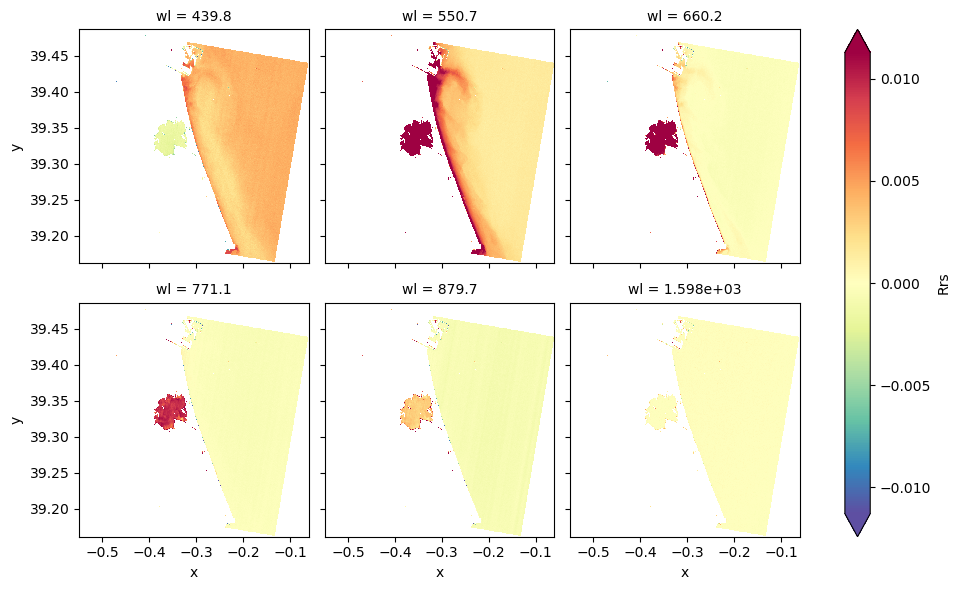

In [39]:

fig = Rrs_.Rrs.sel(wl=[440,550,660,770,880,1600], method='nearest').rio.reproject(4326).plot.imshow(
    col='wl', col_wrap=3, cmap=plt.cm.Spectral_r, robust=True
)
#plt.savefig(root_path+'figure_rtoa.jpg', format='jpg', dpi=300)
plt.show()

### Set output directory
The output L2A image will be saved in hte directory¶

In [40]:
odir='/data/satellite/prisma/zoffoli/L2A'
outfile = os.path.join(odir,l2a_name)

NameError: name 'l2a_name' is not defined

### Set CAMS file
CAMS file should cover the date of the image acquisition

In [ ]:
cams_file = "/data/cams/world/cams_forecast_2021-12.nc"

In [ ]:
process_ = hgrs.Process()
process_.execute(l1c_path,
                 l2c_path,
                 cams_file,
                 
                 )


Check the output L2A product (xarray.Dataset)

In [ ]:
process_.l2_prod

If you want to save the output L2A image into netcdf:

In [ ]:
process_.write_output(outfile)

### check L1C data

In [ ]:
coarsening=1
gamma=0.2
brightness_factor = 1
fig = (l1c_prod.Rtoa[:, ::coarsening, ::coarsening].isel(wl=[30,20,10])**gamma*brightness_factor).plot.imshow(rgb='wl',robust=True)#, subplot_kws=dict(projection= l1c.proj))
fig.axes.set(xticks=[], yticks=[])
fig.axes.set_ylabel('')
fig.axes.set_xlabel('')
fig

In [ ]:
### check L2A output

In [ ]:
#(Rcorr[:, ::coarsening, ::coarsening].isel(wl=[30,20,10])*brightness_factor).plot.imshow(rgb='wl')#, subplot_kws=dict(projection= l1c.proj))
coarsening=1

gamma=0.2
brightness_factor = 1
#fig = (process_.l1c_prod.Rtoa[:, ::coarsening, ::coarsening].isel(wl=[30,20,10])**gamma*brightness_factor).plot.imshow(rgb='wl',robust=True)#, subplot_kws=dict(projection= l1c.proj))
fig =(process_.l2_prod.Rrs[:, ::coarsening, ::coarsening].sel(wl=[670,550,490],method='nearest')).plot.imshow(rgb='wl',robust=True)#, subplot_kws=dict(projection= l1c.proj))ax=fig.axes,
fig.axes.set(xticks=[], yticks=[])
fig.axes.set_ylabel('')
fig.axes.set_xlabel('')
fig

In [ ]:
subset = process_.l2_prod.Rrs.sel(wl=[405,440,490,510,550,600,640,660,695,705,710,750],method='nearest')

fig = subset.plot.imshow(col='wl',col_wrap=4,vmin=0,robust=True,cmap=plt.cm.Spectral_r)
for ax in fig.axs.flat:
    ax.set(xticks=[], yticks=[])
    ax.set_ylabel('')
    ax.set_xlabel('')
fig

In [ ]:


param = 'Rrs'
raster = process_.l2_prod[param] 


#param = 'rho'
#raster = dc_l2c[param] 
cmap='Spectral_r'
#cmap='RdBu_r'
third_dim = 'wl'

wl= raster.wl.data
Nwl = len(wl)
ds = hv.Dataset(raster.persist())
im= ds.to(hv.Image, ['x', 'y'], dynamic=True).opts(cmap= cmap,colorbar=True,clim=(0,0.03)).hist(bin_range=(0,0.02)) 

polys = hv.Polygons([])
box_stream = hv.streams.BoxEdit(source=polys)
dmap, dmap_std=[],[]

def roi_curves(data,ds=ds):    
    if not data or not any(len(d) for d in data.values()):
        return hv.NdOverlay({0: hv.Curve([],'Wavelength (nm)', param)})

    curves,envelope = {},{}
    data = zip(data['x0'], data['x1'], data['y0'], data['y1'])
    for i, (x0, x1, y0, y1) in enumerate(data):
        selection = ds.select(x=(x0, x1), y=(y0, y1))
        mean = selection.aggregate(third_dim, np.mean).data
        std = selection.aggregate(third_dim, np.std).data
        wl = mean.wl

        curves[i]= hv.Curve((wl,mean[param]),'Wavelength (nm)', param) 

    return hv.NdOverlay(curves)


# a bit dirty to have two similar function, but holoviews does not like mixing Curve and Spread for the same stream
def roi_spreads(data,ds=ds):    
    if not data or not any(len(d) for d in data.values()):
        return hv.NdOverlay({0: hv.Curve([],'Wavelength (nm)', param)})

    curves,envelope = {},{}
    data = zip(data['x0'], data['x1'], data['y0'], data['y1'])
    for i, (x0, x1, y0, y1) in enumerate(data):
        selection = ds.select(x=(x0, x1), y=(y0, y1))
        mean = selection.aggregate(third_dim, np.mean).data
        std = selection.aggregate(third_dim, np.std).data
        wl = mean.wl

        curves[i]=  hv.Spread((wl,mean[param],std[param]))
        #curves[i].opts(fill_alpha=0.3)
    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    
hlines = hv.HoloMap({wl[i]: hv.VLine(wl[i]) for i in range(Nwl)},third_dim )


hv.output(widget_location='top_left')

# visualize and play
graphs = ((mean* std *hlines).relabel(param))
layout = (im * polys +graphs    ).opts(
    opts.Curve(width=750,height=500, framewise=True,xlim=(400,1100)), 
    opts.Polygons(fill_alpha=0.2, color='green',line_color='black'), 
    opts.VLine(color='black')).cols(2)
layout 